# 06 — So sánh kiến trúc mô hình: Phát hiện OMI (nhồi máu do tắc mạch)

**Dự án ACS-ECG-AI (Vinmec)** · **Bài toán 4** — phát hiện **occlusion myocardial infarction
(OMI)**: động mạch vành tắc hoàn toàn (TIMI 0–1) xác nhận bằng chụp mạch, cần tái tưới máu cấp cứu.

Đây là **bài toán chính mà paper gốc của bộ dữ liệu đặt ra**. Du *et al.* (*Sci Data* 13:1009, 2026)
công bố dataset kèm đúng một baseline deep learning, và baseline đó làm **OMI/non-OMI nhị phân** —
không phải STEMI, không phải ACS. Notebook này chạy lại bài toán ấy với **mười một kiến trúc**, trong
đó có một bản tái hiện chính kiến trúc baseline của paper.

### Vì sao OMI đáng làm riêng thay vì gộp vào STEMI

Cách phân loại kinh điển chia nhồi máu theo **ST có chênh lên hay không** (STEMI / NSTEMI). Nhưng ST
chênh lên là *dấu hiệu gián tiếp* — có tắc mạch thật mà ST không chênh, và ngược lại. Trong chính bộ
dữ liệu này, **423/1.151 ca OMI (37%) nằm trong nhóm NSTEMI**: mạch tắc hoàn toàn nhưng tiêu chí ST
không bắt được, nên theo phác đồ kinh điển họ không được ưu tiên can thiệp cấp cứu.

Mục 15b của notebook đo riêng hiệu năng trên **đúng phân nhóm NSTEMI này** — đó là chỗ mô hình OMI
có thể tạo giá trị lâm sàng vượt trên cách phân loại cũ, và là kết quả đáng giá nhất ở đây.

### Mốc tham chiếu từ paper

| nguồn | Sens | Spec | PPV | NPV | F1 | Acc |
|---|---|---|---|---|---|---|
| Baseline CNN của paper | 0,697 | 0,873 | 0,277 | 0,976 | 0,396 | 0,861 |
| Chuyên gia ECG #1 (đọc mù) | 0,277 | 0,972 | 0,407 | 0,951 | 0,330 | 0,927 |
| Chuyên gia ECG #2 (đọc mù) | 0,429 | 0,941 | 0,338 | 0,959 | 0,378 | 0,908 |

Baseline của paper đạt **AUROC 0,900** (trung bình 5-fold CV trên tập train của họ). Điểm đáng chú ý:
model có **độ nhạy cao gấp 1,6–2,5 lần chuyên gia đọc mù** — OMI là thứ mắt người khó thấy trên ECG
đơn lẻ, nên đây chính là chỗ AI có lý do tồn tại.

> ⚠️ Các con số trên **không so trực tiếp** được với kết quả trong notebook này: paper đo trên **tập
> test ẩn** (ta không có nhãn) và dùng input **median beat 12×500** (file `.med`), còn ở đây là
> validation tách từ train và input **raw 12×5000**. Xem mục 17.

### Mười một kiến trúc

| mô hình | ý tưởng chính |
|---|---|
| **PlainCNN** | 4 khối Conv-BN-ReLU-MaxPool xếp chồng. Mốc sàn: nếu mô hình phức tạp không thắng được cái này thì độ phức tạp thêm vào là vô ích. |
| **ResNet1D** | Thêm skip connection để mạng sâu vẫn học được. |
| **InceptionTime1D** | Mỗi khối nhìn tín hiệu bằng nhiều độ dài kernel song song (39/19/9), nên bắt được cả sóng nhanh (QRS) lẫn biến thiên chậm (đoạn ST). |
| **CNN+BiLSTM** | CNN rút đặc trưng cục bộ, rồi LSTM hai chiều mô hình hoá quan hệ theo thời gian giữa các nhịp. |
| **SEResNet1D** | ResNet1D + squeeze-excitation sau mỗi khối — model tự học cách cân trọng các kênh đặc trưng. |
| **Transformer1D** | Cắt tín hiệu thành patch theo thời gian, self-attention — bắt phụ thuộc dài hạn mà CNN thuần khó nắm. |
| **TCN1D** | Conv1D giãn nở (dilation) nhiều tầng — receptive field rộng mà vẫn giữ độ phân giải thời gian cao. |
| **XResNet1D** | Biến thể ResNet1D: stem sâu (3 conv nhỏ xếp chồng), nhánh tắt AvgPool+1×1 conv, activation SiLU. |
| **ConvNeXtV2_1D** | Khối depthwise-conv + LayerNorm + MLP mở rộng + Global Response Normalization — bản 1D của ConvNeXt V2. |
| **AiTiAMI** *(tái hiện)* | Lấy cảm hứng từ Lee *et al.*, *Eur Heart J* 2025 (ehaf004, ROMIAE) — ResNet1D sâu/rộng hơn, head avg+max-pool. **Không phải model gốc**, xem cảnh báo ở mục 12. |
| **PaperBaselineCNN** *(tái hiện)* | Kiến trúc baseline của **chính paper bộ dữ liệu này** (Du *et al.*, Fig. 9): 10 lớp conv kernel 71 chia 3 khối, nối dày đặc kiểu DenseNet (mỗi conv nhận concat toàn bộ đầu ra trước đó trong khối). Số kênh khớp đúng sơ đồ. |

Mọi mô hình dùng **cùng một** pipeline tiền xử lý, **cùng một** phép chia train/val theo bệnh nhân và
**cùng một** seed, nên chênh lệch giữa chúng phản ánh kiến trúc chứ không phải may rủi của dữ liệu.
Sau khi train, notebook hợp nhất xác suất bằng **ensemble kiểu WBF**.

Chỉ dùng **ACS-ECG Dataset 2026** — không trộn PTB-XL, vì PTB-XL không có nhãn chụp mạch nên
không thể gán OMI.

Notebook tự chứa, chạy được trên **Google Colab** lẫn máy cá nhân.

## 1. Cài thư viện

Chỉ cài `wfdb` nếu môi trường chưa có. Trên Colab cần cài lại mỗi phiên (~10 giây).

In [22]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("wfdb") is None:
    print("Đang cài wfdb ...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wfdb"], check=True)

import wfdb

print("wfdb", wfdb.__version__)

wfdb 4.3.1


## 2. Cấu hình

Notebook chạy được trên **Google Colab** và **máy cá nhân**, tự nhận diện môi trường.
Chỉ cần sửa đúng một chỗ:

- **Colab** → `DRIVE_PROJECT` (tên thư mục trên Drive chứa `datasets.zip`)
- **Máy cá nhân** → `LOCAL_DATA_ROOT`

Ngoài ra đổi `RUN_MODE` khi muốn chuyển từ chạy thử sang chạy thật.

**Thư mục `outputs/` chỉ giữ hai thứ:** checkpoint mô hình và cache tín hiệu. Hình và bảng số
đều hiển thị ngay trong notebook nên không ghi ra file nữa.

Trên Colab, cache đặt ở `/content` (nhanh, mất khi hết phiên) và được sao lưu lên Drive để phiên
sau khỏi tiền xử lý lại; checkpoint ghi thẳng lên Drive để không mất khi đứt phiên.

In [23]:
import os
from pathlib import Path

import torch

# ===================== CHẾ ĐỘ CHẠY =====================
RUN_MODE = "full"       # "debug" = 200 bản ghi / 3 epoch  |  "full" = toàn bộ / 30 epoch

# ===================== ĐƯỜNG DẪN =======================
IS_COLAB = importlib.util.find_spec("google.colab") is not None

if IS_COLAB:
    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")   # <<< SỬA nếu đặt tên khác
    DRIVE_DATA_ZIP = DRIVE_PROJECT / "datasets.zip"             # <<< SỬA nếu tên zip khác
    DATA_ROOT = Path("/content/datasets")      # giải nén ra đĩa local cho nhanh
    WORK_DIR = Path("/content/work")           # tạm, mất khi hết phiên
    PERSIST_DIR = DRIVE_PROJECT / "outputs"    # bền qua các phiên
else:
    LOCAL_DATA_ROOT = r"C:\Users\anhquan\Workspace\AI_THUC_CHIEN\VSF_Projects\ECG-experiment\datasets"                    # <<< SỬA khi chạy máy cá nhân
    DATA_ROOT = Path(LOCAL_DATA_ROOT)
    WORK_DIR = DATA_ROOT.parent / "outputs"
    PERSIST_DIR = WORK_DIR

CACHE_DIR = WORK_DIR / "cache"                     # cache tín hiệu (sinh lại được)
MODEL_DIR = PERSIST_DIR / "models" / "omi_compare"    # checkpoint (không được mất)
DRIVE_CACHE_DIR = (PERSIST_DIR / "cache") if IS_COLAB else None

# ===================== THAM SỐ =========================
SEED = 42
FS, SIGNAL_LEN, NUM_LEADS = 500, 5000, 12      # 12 chuyển đạo × 10 giây @ 500 Hz
BP_LOW, BP_HIGH, BP_ORDER = 0.5, 40.0, 3       # bandpass Butterworth
VAL_SIZE = 0.15                                 # chia theo bệnh nhân 85/15
LR, WEIGHT_DECAY = 1e-3, 1e-4
EARLY_STOP_PATIENCE, LR_PATIENCE = 10, 5
ECE_BINS = 10
TARGET_LABEL = "OMI"
CLASS_NAME = "OMI"

# Số ca theo paper, tính trên TOÀN BỘ 19.955 bản ghi (Table 3 + mục Data overview).
# OMI = 807 (trong nhóm STEMI) + 467 (trong nhóm NSTEMI) = 1.274.
# train.csv chỉ giữ 90% (10% còn lại là test ẩn), nên số KỲ VỌNG đếm được = paper × 0,9 —
# đối chiếu với con số đã nhân 0,9 chặt hơn hẳn so trực tiếp với con số gốc.
PAPER_COUNTS = {"STEMI": 1513, "NSTEMI": 1274, "UA": 6197, "AMI": 2933, "OMI": 1274}
TRAIN_FRAC = 0.90
SANITY_TOL = 0.12

# ===================== SUY RA ==========================
GPU_AVAILABLE = torch.cuda.is_available()
DEVICE = torch.device("cuda" if GPU_AVAILABLE else "cpu")
DEBUG_LIMIT = 200
EPOCHS = 3 if RUN_MODE == "debug" else 30
BATCH_SIZE = 8 if RUN_MODE == "debug" else (64 if GPU_AVAILABLE else 16)
USE_AMP = GPU_AVAILABLE

print("Môi trường :", "Google Colab" if IS_COLAB else "máy cá nhân")
print("Thiết bị   :", DEVICE)
print("Chế độ     :", RUN_MODE, f"({EPOCHS} epoch, batch {BATCH_SIZE})")
print("Nhãn đích  :", TARGET_LABEL)

Môi trường : Google Colab
Thiết bị   : cuda
Chế độ     : full (30 epoch, batch 64)
Nhãn đích  : OMI


### 2b. Chuẩn bị dữ liệu

Trên máy cá nhân cell này chỉ tạo thư mục. Trên Colab nó mount Drive (sẽ hiện popup xin quyền —
đây là thao tác thủ công duy nhất), copy `datasets.zip` về `/content` rồi giải nén.

Phải đi vòng qua zip vì bộ dữ liệu có **59.867 file**, mà Drive tính mỗi lần mở file là một lệnh
gọi mạng — đọc trực tiếp từ Drive sẽ chậm hơn hàng chục lần.

In [24]:
import shutil
import time
import zipfile


def _locate_data_root(search_root: Path) -> Path:
    """Tìm thư mục thật chứa dữ liệu, chịu được việc zip có bọc thêm lớp thư mục."""
    wanted = {"csv", "row_data", "raw_data", "med_data"}
    best, best_score = search_root, -1
    for cand in [search_root, *[p for p in search_root.rglob("*") if p.is_dir()]]:
        try:
            names = {c.name.lower() for c in cand.iterdir() if c.is_dir()}
        except OSError:
            continue
        if len(names & wanted) > best_score:
            best, best_score = cand, len(names & wanted)
        if best_score >= 2:
            break
    return best


def stage_colab_data() -> Path:
    marker = DATA_ROOT / ".staged_ok"
    if marker.exists():
        real = Path(marker.read_text().strip())
        print("Dữ liệu đã sẵn sàng:", real)
        return real

    if not DRIVE_DATA_ZIP.exists():
        có_gì = sorted(p.name for p in DRIVE_PROJECT.iterdir())[:40]
        raise FileNotFoundError(
            f"Không thấy {DRIVE_DATA_ZIP}\nTrong {DRIVE_PROJECT} hiện có: {có_gì}"
        )

    local_zip = Path("/content/_dataset.zip")
    size = DRIVE_DATA_ZIP.stat().st_size
    if not (local_zip.exists() and local_zip.stat().st_size == size):
        print(f"Copy zip {size / 1024 ** 3:.2f} GB từ Drive ...")
        t0 = time.time()
        shutil.copy2(DRIVE_DATA_ZIP, local_zip)
        print(f"  {time.time() - t0:.0f}s")

    extract_to = Path("/content/_extract")
    if extract_to.exists():
        shutil.rmtree(extract_to)
    print("Giải nén ...")
    t0 = time.time()
    with zipfile.ZipFile(local_zip) as zf:
        zf.extractall(extract_to)
    print(f"  {time.time() - t0:.0f}s")

    real = _locate_data_root(extract_to)
    real.mkdir(parents=True, exist_ok=True)
    (real / ".staged_ok").write_text(str(real))
    return real


if IS_COLAB:
    if str(DRIVE_PROJECT).startswith(("http://", "https://", "www.")):
        raise ValueError(
            "DRIVE_PROJECT đang là URL chia sẻ Drive. Phải là đường dẫn sau khi mount:\n"
            '    DRIVE_PROJECT = Path("/content/drive/MyDrive/ACS-ECG-AI")'
        )
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    if not DRIVE_PROJECT.exists():
        my = Path("/content/drive/MyDrive")
        có_gì = sorted(p.name for p in my.iterdir() if p.is_dir())[:40] if my.exists() else []
        raise FileNotFoundError(
            f"Không thấy {DRIVE_PROJECT}\nCác thư mục trong MyDrive: {có_gì}"
        )

for d in [CACHE_DIR, MODEL_DIR] + ([DRIVE_CACHE_DIR] if DRIVE_CACHE_DIR else []):
    d.mkdir(parents=True, exist_ok=True)

if IS_COLAB:
    DATA_ROOT = stage_colab_data()

print("DATA_ROOT:", DATA_ROOT, "| tồn tại:", DATA_ROOT.exists())

Giải nén ...
  27s
DATA_ROOT: /content/_extract/datasets | tồn tại: True


## 3. Seed & GPU

In [25]:
import random

import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Input cố định (12 × 5000) nên cuDNN chọn thuật toán nhanh nhất một lần rồi giữ nguyên.
# Đánh đổi: epoch đầu chậm hơn vài giây, và kết quả không tái lập chính xác 100%.
torch.backends.cudnn.benchmark = GPU_AVAILABLE

print("torch", torch.__version__, "| GPU:", torch.cuda.get_device_name(0) if GPU_AVAILABLE else "không có")
if IS_COLAB and not GPU_AVAILABLE:
    print("\n" + "!" * 70)
    print("!! COLAB KHÔNG CÓ GPU -> Runtime > Change runtime type > GPU, rồi Run all lại.")
    print("!" * 70)

torch 2.11.0+cu128 | GPU: NVIDIA A100-SXM4-80GB


## 4. Dữ liệu và nhãn

Nhãn chỉ có trong `train.csv` (phần 90% chính thức). `test.csv` là tập test ẩn, không có cột nhãn
và **không bao giờ được đọc** trong notebook này.

Nhãn đích lấy thẳng cột `OMI`. Theo định nghĩa của paper, `OMI = 1` nghĩa là **báo cáo chụp mạch ghi
nhận tắc cấp tính với TIMI flow 0–1 ở mạch thủ phạm trước khi can thiệp PCI** — tức nhãn dựa trên
giải phẫu mạch thật, không phải suy ra từ hình dạng ECG.

Sanity check đối chiếu với số ca của paper **đã nhân 0,9** (phần mà `train.csv` nắm giữ), thay vì so
thẳng với con số tính trên toàn bộ 19.955 bản ghi.

In [26]:
import pandas as pd

pd.set_option("display.width", 200)


def find_dir(root: Path, names):
    wanted = {n.lower() for n in names}
    for c in sorted(root.iterdir()):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    for c in root.rglob("*"):
        if c.is_dir() and c.name.lower() in wanted:
            return c
    return None


RAW_DIR = find_dir(DATA_ROOT, ["row_data", "raw_data"])
CSV_DIR = find_dir(DATA_ROOT, ["CSV", "csv"])
assert RAW_DIR and CSV_DIR, f"Không thấy row_data/ hoặc CSV/ trong {DATA_ROOT}"

df_raw = pd.read_csv(CSV_DIR / "train.csv")
df_raw["record_stem"] = df_raw["ecg_row_record"].astype(str).str.replace(".dat", "", regex=False)

COL_PATIENT, COL_AGE, COL_GENDER = "Patient_id", "age", "gender"
print(f"{len(df_raw):,} bản ghi | {df_raw[COL_PATIENT].nunique():,} bệnh nhân | "
      f"{len(list(RAW_DIR.glob('*.dat'))):,} file .dat")

# --- Sanity check: so với (số của paper × 0,9) vì train.csv chỉ giữ 90% ---
print(f"\n{'nhãn':<8}{'đếm được':>11}{'kỳ vọng':>10}{'lệch':>9}")
ok_all = True
for _name, _full in PAPER_COUNTS.items():
    got = int(df_raw[_name].sum())
    exp = _full * TRAIN_FRAC
    delta = (got - exp) / exp
    ok_all &= abs(delta) <= SANITY_TOL
    print(f"{_name:<8}{got:>11,}{exp:>10,.0f}{delta:>8.1%}   "
          f"{'OK' if abs(delta) <= SANITY_TOL else 'LỆCH'}")
if not ok_all:
    print(f"\n!! CẢNH BÁO: có nhãn lệch quá ±{SANITY_TOL:.0%} so với kỳ vọng — kiểm tra nguồn dữ liệu.")

# --- Nhãn đích ---
df_all = df_raw.copy()
df_all[TARGET_LABEL] = df_all["OMI"].astype(int)
print("\nNhãn = cột OMI (tắc cấp hoàn toàn TIMI 0-1 theo báo cáo chụp mạch, trước PCI)")

n_pos = int(df_all[TARGET_LABEL].sum())
print(f"\nNhãn {TARGET_LABEL}: {n_pos:,} dương ({n_pos / len(df_all):.2%}) / "
      f"{len(df_all) - n_pos:,} âm")

17,960 bản ghi | 17,018 bệnh nhân | 19,955 file .dat

nhãn       đếm được   kỳ vọng     lệch
STEMI         1,442     1,362    5.9%   OK
NSTEMI        1,235     1,147    7.7%   OK
UA            6,213     5,577   11.4%   OK
AMI           2,679     2,640    1.5%   OK
OMI           1,151     1,147    0.4%   OK

Nhãn = cột OMI (tắc cấp hoàn toàn TIMI 0-1 theo báo cáo chụp mạch, trước PCI)

Nhãn OMI: 1,151 dương (6.41%) / 16,809 âm


### 4b. OMI chồng lấn thế nào với cách phân loại kinh điển

Bảng này là lý do bài toán OMI tồn tại. Nếu OMI trùng khít với STEMI thì làm riêng nó là vô nghĩa —
cứ dùng model STEMI là xong. Thực tế không phải vậy.

Hai con số cần nhìn:

- **OMI trong nhóm NSTEMI** — mạch tắc hoàn toàn nhưng ST không chênh lên. Phác đồ kinh điển xếp họ
  vào diện "không cấp cứu", trong khi giải phẫu mạch nói ngược lại. Đây là nhóm bị bỏ sót.
- **OMI trong nhóm STEMI** — phần "dễ", model STEMI sẵn có đã bắt được kha khá.

Chiều ngược lại cũng đáng chú ý: không phải ca STEMI nào cũng là OMI (ST chênh lên do nguyên nhân
khác, hoặc mạch đã tự thông trước khi chụp).

In [27]:
_omi = df_all["OMI"].astype(int) == 1
_n_omi = int(_omi.sum())

_rows = []
for _c in ["STEMI", "NSTEMI", "UA", "AMI", "CTO", "PCI"]:
    _sub = df_all[_c].astype(int) == 1
    _n = int(_sub.sum())
    _k = int((_sub & _omi).sum())
    _rows.append({
        "Nhóm": _c,
        "n trong nhóm": _n,
        "trong đó OMI": _k,
        "tỷ lệ OMI của nhóm (%)": round(100 * _k / _n, 1) if _n else float("nan"),
        "chiếm % tổng OMI": round(100 * _k / _n_omi, 1) if _n_omi else float("nan"),
    })

_neither = int((_omi & (df_all["STEMI"].astype(int) == 0)
                & (df_all["NSTEMI"].astype(int) == 0)).sum())
_rows.append({"Nhóm": "(OMI ngoài cả STEMI lẫn NSTEMI)", "n trong nhóm": _neither,
              "trong đó OMI": _neither, "tỷ lệ OMI của nhóm (%)": 100.0,
              "chiếm % tổng OMI": round(100 * _neither / _n_omi, 1) if _n_omi else float("nan")})

print(f"Tổng số ca OMI: {_n_omi:,}\n")
display(pd.DataFrame(_rows).set_index("Nhóm"))

_omi_nstemi = int((_omi & (df_all["NSTEMI"].astype(int) == 1)).sum())
_omi_stemi = int((_omi & (df_all["STEMI"].astype(int) == 1)).sum())
print(f"\nOMI ẩn trong NSTEMI : {_omi_nstemi:,} ca "
      f"({100 * _omi_nstemi / _n_omi:.1f}% tổng số OMI)")
print(f"OMI trong STEMI     : {_omi_stemi:,} ca "
      f"({100 * _omi_stemi / _n_omi:.1f}% tổng số OMI)")
print("\nNhóm thứ nhất là chỗ tiêu chí ST chênh lên bỏ sót mà mạch vẫn tắc hoàn toàn —")
print("mục 15b đo riêng hiệu năng trên đúng nhóm này.")

Tổng số ca OMI: 1,151



,n trong nhóm,trong đó OMI,tỷ lệ OMI của nhóm (%),chiếm % tổng OMI
Nhóm,,,,
STEMI,1442,727,50.4,63.2
NSTEMI,1235,423,34.3,36.8
UA,6213,0,0.0,0.0
AMI,2679,1151,43.0,100.0
CTO,957,0,0.0,0.0
PCI,4541,648,14.3,56.3
(OMI ngoài cả STEMI lẫn NSTEMI),1,1,100.0,0.1



OMI ẩn trong NSTEMI : 423 ca (36.8% tổng số OMI)
OMI trong STEMI     : 727 ca (63.2% tổng số OMI)

Nhóm thứ nhất là chỗ tiêu chí ST chênh lên bỏ sót mà mạch vẫn tắc hoàn toàn —
mục 15b đo riêng hiệu năng trên đúng nhóm này.


## 5. Lấy mẫu khi chạy thử

Ở `RUN_MODE="debug"` lấy 200 bản ghi **stratified** theo nhãn, để tập mẫu không rơi vào toàn 0
hoặc toàn 1 (khi đó mọi metric sẽ vô định).

In [28]:
from sklearn.model_selection import train_test_split

if RUN_MODE == "debug" and len(df_all) > DEBUG_LIMIT:
    df, _ = train_test_split(df_all, train_size=DEBUG_LIMIT,
                             stratify=df_all[TARGET_LABEL], random_state=SEED)
    df = df.reset_index(drop=True)
else:
    df = df_all.reset_index(drop=True)

n_pos = int(df[TARGET_LABEL].sum())
print(f"Dùng {len(df):,} bản ghi | {n_pos:,} dương ({n_pos / len(df):.2%})")
assert 0 < n_pos < len(df), "Tập chỉ có một lớp — không train được."

Dùng 17,960 bản ghi | 1,151 dương (6.41%)


## 7. Tiền xử lý và cache

Với mỗi bản ghi: đọc WFDB → NaN→0 → cắt/đệm về đúng 5000 mẫu → bandpass Butterworth 0,5–40 Hz
(`filtfilt`, zero-phase). **Chuẩn hoá z-score làm sau**, ở bước 9, với mean/std tính riêng trên tập
train để không rò rỉ thống kê của val sang train.

Lọc lại toàn bộ ở mỗi epoch là nút thắt cổ chai, nên tín hiệu đã lọc được cache **một lần** vào
memmap `float16` (~2,2 GB cho 17.960 bản ghi). Cache nối tiếp được nếu bị ngắt giữa chừng, và trên
Colab được sao lưu lên Drive.

> **Dùng chung cache với notebook 01/03.** Ở `RUN_MODE="full"`, danh sách bản ghi ở đây giống hệt
> hai notebook kia (cùng toàn bộ `train.csv`, chỉ khác cột nhãn), nên tên file cache — vốn băm từ
> danh sách `record_stem` — trùng nhau và bước tiền xử lý được bỏ qua hoàn toàn. Ở `debug` thì mẫu
> stratified theo nhãn OMI khác mẫu theo nhãn STEMI, nên cache riêng, đúng như mong muốn.

> **Hai bản ghi lỗi trong dữ liệu gốc.** `03228` và `14262` có file `.dat` chỉ chứa 3.500/5.000 mẫu,
> khiến `wfdb.rdrecord()` báo lỗi. Hàm dưới bắt lỗi đó, đọc phần thực có rồi để bước zero-pad bù nốt.

In [29]:
import hashlib
import json

from scipy.signal import butter, filtfilt

_B, _A = butter(BP_ORDER, [BP_LOW / (FS / 2), BP_HIGH / (FS / 2)], btype="band")
TRUNCATED = []


def load_signal(stem: str) -> np.ndarray:
    path = str(RAW_DIR / stem)
    try:
        rec = wfdb.rdrecord(path)
    except ValueError:                     # .dat ngắn hơn header khai báo
        n_sig = int((RAW_DIR / f"{stem}.hea").read_text().splitlines()[0].split()[1])
        n = (RAW_DIR / f"{stem}.dat").stat().st_size // (n_sig * 2)
        rec = wfdb.rdrecord(path, sampto=n)
        TRUNCATED.append(stem)
    return np.asarray(rec.p_signal, dtype=np.float32).T


def preprocess(sig: np.ndarray) -> np.ndarray:
    sig = np.nan_to_num(sig, nan=0.0, posinf=0.0, neginf=0.0)
    if sig.shape[1] < SIGNAL_LEN:
        sig = np.pad(sig, ((0, 0), (0, SIGNAL_LEN - sig.shape[1])))
    return np.ascontiguousarray(filtfilt(_B, _A, sig[:, :SIGNAL_LEN], axis=1), dtype=np.float32)


records = df["record_stem"].tolist()
_hash = hashlib.md5("|".join(records).encode()).hexdigest()[:8]
CACHE_NPY = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.npy"
CACHE_META = CACHE_DIR / f"sig_{RUN_MODE}_n{len(df)}_{_hash}.meta.json"


def _complete(meta_p: Path, npy_p: Path) -> bool:
    if not (meta_p.exists() and npy_p.exists()):
        return False
    try:
        return json.loads(meta_p.read_text()).get("n_done", 0) >= len(records)
    except (OSError, ValueError):
        return False


def build_cache() -> np.ndarray:
    # Colab: thử lấy lại cache của phiên trước từ Drive
    if DRIVE_CACHE_DIR and not _complete(CACHE_META, CACHE_NPY):
        d_npy, d_meta = DRIVE_CACHE_DIR / CACHE_NPY.name, DRIVE_CACHE_DIR / CACHE_META.name
        if _complete(d_meta, d_npy):
            print(f"Lấy cache từ Drive ({d_npy.stat().st_size / 1024 ** 3:.2f} GB) ...")
            t0 = time.time()
            shutil.copy2(d_npy, CACHE_NPY)
            shutil.copy2(d_meta, CACHE_META)
            print(f"  {time.time() - t0:.0f}s — bỏ qua tiền xử lý")

    if _complete(CACHE_META, CACHE_NPY):
        print("Cache đã đầy đủ:", CACHE_NPY.name)
        return np.load(CACHE_NPY, mmap_mode="r")

    meta = json.loads(CACHE_META.read_text()) if CACHE_META.exists() else {}
    start = int(meta.get("n_done", 0)) if CACHE_NPY.exists() else 0
    if start:
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="r+")
        print(f"Build tiếp từ {start}/{len(records)}")
    else:
        print(f"Build cache {len(records):,} bản ghi "
              f"(~{len(records) * NUM_LEADS * SIGNAL_LEN * 2 / 1024 ** 3:.2f} GB)")
        arr = np.lib.format.open_memmap(CACHE_NPY, mode="w+", dtype=np.float16,
                                        shape=(len(records), NUM_LEADS, SIGNAL_LEN))

    t0 = time.time()
    step = max(1, len(records) // 8)
    for i in range(start, len(records)):
        arr[i] = preprocess(load_signal(records[i])).astype(np.float16)
        if (i + 1) % step == 0 or i + 1 == len(records):
            arr.flush()
            CACHE_META.write_text(json.dumps({"n_done": i + 1}))
            el = max(time.time() - t0, 1e-6)
            done = i + 1 - start
            print(f"  {i + 1:>6,}/{len(records):,}  {done / el:5.0f} rec/s  "
                  f"ETA {(len(records) - i - 1) / (done / el):4.0f}s")
    del arr
    print(f"Xong trong {time.time() - t0:.0f}s")

    if DRIVE_CACHE_DIR:
        print("Sao lưu cache lên Drive ...")
        shutil.copy2(CACHE_NPY, DRIVE_CACHE_DIR / CACHE_NPY.name)
        shutil.copy2(CACHE_META, DRIVE_CACHE_DIR / CACHE_META.name)
    return np.load(CACHE_NPY, mmap_mode="r")


CACHE = build_cache()
print("Cache:", CACHE.shape, CACHE.dtype)
if TRUNCATED:
    print(f"Bản ghi bị cắt ngắn, đã zero-pad: {TRUNCATED}")

Lấy cache từ Drive (2.01 GB) ...
  50s — bỏ qua tiền xử lý
Cache đã đầy đủ: sig_full_n17960_c20c6dba.npy
Cache: (17960, 12, 5000) float16


## 9. Chia train/val theo bệnh nhân

Bắt buộc chia theo `Patient_id`: một bệnh nhân có thể có nhiều ECG trong 7 ngày trước DSA, chia theo
bản ghi sẽ khiến cùng một người xuất hiện ở cả train lẫn val.

Stratify ở **cấp bệnh nhân** (lấy `max` nhãn của người đó) — cần thiết vì có bệnh nhân mang nhãn
không đồng nhất giữa các bản ghi của chính mình.

Ngay sau khi chia, mean/std cho z-score được tính **chỉ trên các bản ghi thuộc train**.

In [30]:
pat = df.groupby(COL_PATIENT)[TARGET_LABEL].max().reset_index()
strat = pat[TARGET_LABEL] if pat[TARGET_LABEL].value_counts().min() >= 2 else None
pat_tr, pat_va = train_test_split(pat, test_size=VAL_SIZE, stratify=strat, random_state=SEED)

train_idx = df.index[df[COL_PATIENT].isin(set(pat_tr[COL_PATIENT]))].to_numpy()
val_idx = df.index[df[COL_PATIENT].isin(set(pat_va[COL_PATIENT]))].to_numpy()
y = df[TARGET_LABEL].values.astype(np.float32)

assert not (set(pat_tr[COL_PATIENT]) & set(pat_va[COL_PATIENT])), "RÒ RỈ: bệnh nhân ở cả 2 tập"
print("Giao nhau patient_id: RỖNG -> OK\n")

display(pd.DataFrame({
    "tập": ["train", "val"],
    "bệnh nhân": [len(pat_tr), len(pat_va)],
    "bản ghi": [len(train_idx), len(val_idx)],
    "dương": [int(y[train_idx].sum()), int(y[val_idx].sum())],
    "tỷ lệ dương": [f"{y[train_idx].mean():.2%}", f"{y[val_idx].mean():.2%}"],
}))


def norm_stats(idx, chunk=256):
    order = np.sort(np.asarray(idx))
    s = np.zeros(NUM_LEADS)
    ss = np.zeros(NUM_LEADS)
    cnt = 0
    for i in range(0, len(order), chunk):
        b = np.asarray(CACHE[order[i:i + chunk]], dtype=np.float64)
        s += b.sum(axis=(0, 2))
        ss += (b ** 2).sum(axis=(0, 2))
        cnt += b.shape[0] * b.shape[2]
    m = s / cnt
    return m.astype(np.float32), np.sqrt(np.maximum(ss / cnt - m ** 2, 1e-12)).astype(np.float32)


LEAD_MEAN, LEAD_STD = norm_stats(train_idx)
print(f"\nz-score fit trên {len(train_idx):,} bản ghi TRAIN")

Giao nhau patient_id: RỖNG -> OK



,tập,bệnh nhân,bản ghi,dương,tỷ lệ dương
0,train,14465,15256,977,6.40%
1,val,2553,2704,174,6.43%



z-score fit trên 15,256 bản ghi TRAIN


## 10. Dataset & DataLoader

In [31]:
from torch.utils.data import DataLoader, Dataset


class ECGDataset(Dataset):
    def __init__(self, indices, labels):
        self.indices = np.asarray(indices)
        self.labels = np.asarray(labels, dtype=np.float32)
        self.mean = LEAD_MEAN.reshape(-1, 1)
        self.std = LEAD_STD.reshape(-1, 1)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        x = np.asarray(CACHE[self.indices[i]], dtype=np.float32)
        return torch.from_numpy((x - self.mean) / self.std), torch.tensor(self.labels[i])


# Windows tạo worker bằng spawn (mỗi worker nạp lại cả notebook) nên để 0; Linux dùng fork -> 2
NUM_WORKERS = 0 if os.name == "nt" else 2
_extra = dict(persistent_workers=True, prefetch_factor=4) if NUM_WORKERS else {}

train_loader = DataLoader(ECGDataset(train_idx, y[train_idx]), batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)
val_loader = DataLoader(ECGDataset(val_idx, y[val_idx]), batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=GPU_AVAILABLE, **_extra)

xb, yb = next(iter(train_loader))
print(f"batch: {tuple(xb.shape)} {xb.dtype} | nhãn {tuple(yb.shape)} | "
      f"{len(train_loader)} batch train, {len(val_loader)} batch val")

batch: (64, 12, 5000) torch.float32 | nhãn (64,) | 239 batch train, 43 batch val


## 11. Hàm tính metric

`compute_metrics` an toàn với tập nhỏ: khi chỉ có một lớp hoặc mẫu số bằng 0, trả `nan` thay vì
ném lỗi hay trả 0 gây hiểu nhầm.

`per_class_report` cho bảng tách riêng **lớp âm tính (0)** và **lớp dương tính (1)** — mỗi lớp có
Precision/Recall/F1/Support riêng, kèm hai dòng trung bình macro và weighted.

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import (average_precision_score, brier_score_loss, confusion_matrix,
                             precision_recall_fscore_support, roc_auc_score)

plt.rcParams["figure.dpi"] = 110


def _div(a, b):
    return float(a) / float(b) if b else float("nan")


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob, dtype=np.float64).ravel()
    y_pred = (y_prob >= threshold).astype(int)
    two = len(np.unique(y_true)) == 2
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "auroc": roc_auc_score(y_true, y_prob) if two else float("nan"),
        "auprc": average_precision_score(y_true, y_prob) if two else float("nan"),
        "sensitivity": _div(tp, tp + fn), "specificity": _div(tn, tn + fp),
        "ppv": _div(tp, tp + fp), "npv": _div(tn, tn + fn),
        "f1": _div(2 * tp, 2 * tp + fp + fn),
        "accuracy": _div(tp + tn, tp + tn + fp + fn),
        "brier": float(brier_score_loss(y_true, y_prob)) if two else float("nan"),
        "threshold": float(threshold),
        "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        "n": int(len(y_true)), "n_pos": int(y_true.sum()),
    }


def per_class_report(y_true, y_prob, threshold):
    """Bảng metric TÁCH RIÊNG cho lớp 0 và lớp 1, kiểu classification_report của sklearn."""
    y_true = np.asarray(y_true).astype(int).ravel()
    y_pred = (np.asarray(y_prob).ravel() >= threshold).astype(int)
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1], zero_division=0)
    rows = [
        {"Class": f"Negative (0) — không {CLASS_NAME}", "Precision": p[0], "Recall": r[0],
         "F1": f[0], "Support": int(s[0])},
        {"Class": f"Positive (1) — {CLASS_NAME}", "Precision": p[1], "Recall": r[1],
         "F1": f[1], "Support": int(s[1])},
    ]
    w = s / s.sum()
    rows.append({"Class": "macro avg", "Precision": p.mean(), "Recall": r.mean(),
                 "F1": f.mean(), "Support": int(s.sum())})
    rows.append({"Class": "weighted avg", "Precision": float(p @ w), "Recall": float(r @ w),
                 "F1": float(f @ w), "Support": int(s.sum())})
    return pd.DataFrame(rows).set_index("Class")


def style_df(df, pct_cols):
    fmt = {c: "{:.4f}" for c in pct_cols}
    fmt.update({c: "{:,d}" for c in df.columns if c not in pct_cols and df[c].dtype.kind in "iu"})
    try:
        return df.style.format(fmt, na_rep="n/a").background_gradient(
            cmap="Blues", vmin=0, vmax=1, subset=[c for c in pct_cols if c in df.columns])
    except Exception:
        return df.round(4)


print("self-test:", {k: round(v, 3) for k, v in
                     compute_metrics([0, 0, 1, 1], [.1, .4, .35, .8]).items()
                     if k in ("auroc", "f1", "sensitivity")})

self-test: {'auroc': np.float64(0.75), 'sensitivity': 0.5, 'f1': 0.667}


## 12. Mười một kiến trúc

Tất cả nhận input `(batch, 12, 5000)` và trả về **một logit** cho mỗi mẫu, nên có thể thay thế nhau
trong đúng một vòng lặp huấn luyện.

Cả mười một đều hạ chiều thời gian khá mạnh (5000 → vài chục/vài trăm) trước khi gộp, vì tín hiệu 10
giây ở 500 Hz là quá dài để giữ nguyên độ phân giải qua nhiều tầng.

> ⚠️ **`AiTiAMI` là tái hiện theo mô tả kiến trúc, không phải model/trọng số gốc.** Lee *et al.*
> (*Eur Heart J* 2025, ehaf004 — nghiên cứu ROMIAE) chỉ mô tả AiTiAMI v1.00.00 của Medical AI Co.
> là "an advanced algorithm... built on a residual neural network", đầu vào 500Hz 12 chuyển đạo
> thô, đầu ra điểm xác suất AMI 0-100. Không có chi tiết số khối, độ sâu, hay trọng số công khai —
> class `AiTiAMI` dưới đây là một ResNet1D sâu/rộng hơn `ResNet1D` sẵn có, kernel hẹp hơn (5 thay
> vì 7), head kết hợp avg+max-pool.

> ⚠️ **`PaperBaselineCNN` bám sát sơ đồ nhưng không phải bản sao chạy được của paper.** Fig. 9 của
> Du *et al.* cho đủ số kênh vào/ra, kernel (71), stride (1) và padding (35) của cả 10 lớp conv, nên
> phần **kết nối và số kênh được tái hiện chính xác** — mỗi conv trong một khối nhận `concat` toàn bộ
> đầu ra trước đó của khối, kiểu DenseNet. Ba chỗ notebook này **cố ý làm khác**:
>
> 1. **Input `raw 12×5000` thay vì `median beat 12×500`.** Paper dùng file `.med`; ở đây mọi model
>    ăn chung tín hiệu thô để so sánh giữa 11 kiến trúc là công bằng. Đây là khác biệt lớn nhất và
>    là lý do chính khiến không thể kỳ vọng tái lập con số AUROC 0,900.
> 2. **Thêm BatchNorm sau mỗi conv.** Sơ đồ gốc chỉ vẽ conv → relu. Không có BN, mạng 10 lớp conv
>    kernel 71 rất dễ phân kỳ ở LR 1e-3 dùng chung cho cả bộ.
> 3. **Head là `AdaptiveAvgPool1d(1)` → `Linear(16, 1)` một logit** thay vì `fc` 2 lớp + CrossEntropy
>    như paper, để khớp với `BCEWithLogitsLoss(pos_weight=...)` mà cả 11 model ở đây dùng chung.

In [33]:
import torch.nn as nn


# ---------------------------------------------------------------- 1. PlainCNN
class PlainCNN(nn.Module):
    """Mốc sàn: Conv-BN-ReLU-MaxPool xếp chồng, không có gì đặc biệt."""

    def __init__(self, channels=(32, 64, 128, 256)):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in channels:
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.features(x)).squeeze(-1)


# ---------------------------------------------------------------- 2. ResNet1D
class ResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class ResNet1D(nn.Module):
    """Skip connection giúp gradient đi xuyên qua mạng sâu."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(ResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 3. InceptionTime1D
class InceptionModule(nn.Module):
    """Nhiều độ dài kernel song song -> bắt được cả sóng nhanh lẫn biến thiên chậm."""

    def __init__(self, c_in, n_filters=32, kernels=(39, 19, 9), bottleneck=32):
        super().__init__()
        self.bottleneck = nn.Conv1d(c_in, bottleneck, 1, bias=False)
        self.convs = nn.ModuleList(
            [nn.Conv1d(bottleneck, n_filters, k, padding=k // 2, bias=False) for k in kernels])
        self.pool_conv = nn.Sequential(nn.MaxPool1d(3, stride=1, padding=1),
                                       nn.Conv1d(c_in, n_filters, 1, bias=False))
        self.bn = nn.BatchNorm1d(n_filters * (len(kernels) + 1))
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        b = self.bottleneck(x)
        return self.relu(self.bn(torch.cat([c(b) for c in self.convs] + [self.pool_conv(x)], 1)))


class InceptionTime1D(nn.Module):
    def __init__(self, n_filters=32, depth=6):
        super().__init__()
        # hạ tần số ngay từ đầu, nếu không 5000 mẫu × nhiều kênh sẽ quá nặng
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 4, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True))
        c_out = n_filters * 4
        self.blocks = nn.ModuleList()
        self.shortcuts = nn.ModuleList()
        self.pools = nn.ModuleList()
        c_in = 32
        res_c = 32          # số kênh của tensor dùng làm residual, KHÁC c_in của khối hiện tại
        for d in range(depth):
            self.blocks.append(InceptionModule(c_in, n_filters))
            # residual mỗi 3 khối, kèm hạ chiều thời gian
            if d % 3 == 2:
                self.shortcuts.append(nn.Sequential(nn.Conv1d(res_c, c_out, 1, bias=False),
                                                    nn.BatchNorm1d(c_out)))
                self.pools.append(nn.MaxPool1d(4))
                res_c = c_out
            else:
                self.shortcuts.append(None)
                self.pools.append(None)
            c_in = c_out
        self.relu = nn.ReLU(inplace=True)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_out, 1))

    def forward(self, x):
        x = self.stem(x)
        res = x
        for blk, short, pool in zip(self.blocks, self.shortcuts, self.pools):
            x = blk(x)
            if short is not None:
                x = self.relu(x + short(res))
                x = pool(x)
                res = x
        return self.head(x).squeeze(-1)


# ---------------------------------------------------------------- 4. CNN + BiLSTM
class CNNBiLSTM(nn.Module):
    """CNN rút đặc trưng cục bộ, BiLSTM mô hình hoá quan hệ theo thời gian giữa các nhịp."""

    def __init__(self, hidden=128):
        super().__init__()
        layers, c_in = [], NUM_LEADS
        for c_out in (32, 64, 128):
            layers += [nn.Conv1d(c_in, c_out, 7, padding=3, bias=False),
                       nn.BatchNorm1d(c_out), nn.ReLU(inplace=True), nn.MaxPool1d(4)]
            c_in = c_out
        self.cnn = nn.Sequential(*layers)                       # 5000 -> ~78
        self.lstm = nn.LSTM(c_in, hidden, batch_first=True, bidirectional=True)
        self.head = nn.Sequential(nn.Dropout(0.3), nn.Linear(hidden * 2, 1))

    def forward(self, x):
        h = self.cnn(x).transpose(1, 2)                          # (B, T, C)
        out, _ = self.lstm(h)
        return self.head(out.mean(dim=1)).squeeze(-1)            # gộp trung bình theo thời gian

# ---------------------------------------------------------------- 5. SEResNet1D
class SEBlock1D(nn.Module):
    """Squeeze-excitation: học trọng số quan trọng theo từng kênh (feature map)."""

    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(nn.Linear(channels, hidden), nn.ReLU(inplace=True),
                                nn.Linear(hidden, channels), nn.Sigmoid())

    def forward(self, x):
        w = self.fc(self.pool(x).squeeze(-1)).unsqueeze(-1)
        return x * w


class SEResidualBlock1D(nn.Module):
    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.se = SEBlock1D(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.se(self.bn2(self.conv2(out)))
        return self.relu(out + idt)


class SEResNet1D(nn.Module):
    """ResNet1D + squeeze-excitation sau mỗi khối."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(SEResidualBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 6. Transformer1D
class Transformer1D(nn.Module):
    """Cắt tín hiệu thành patch theo thời gian, học vị trí, qua self-attention."""

    def __init__(self, patch_len=250, d_model=128, n_heads=4, n_layers=4, dropout=0.1):
        super().__init__()
        assert SIGNAL_LEN % patch_len == 0
        n_patches = SIGNAL_LEN // patch_len
        self.patch_len = patch_len
        self.proj = nn.Linear(NUM_LEADS * patch_len, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        layer = nn.TransformerEncoderLayer(d_model, n_heads, dim_feedforward=d_model * 4,
                                           dropout=dropout, batch_first=True, activation="gelu")
        self.encoder = nn.TransformerEncoder(layer, n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(d_model, 1))

    def forward(self, x):
        b = x.shape[0]
        patches = x.unfold(-1, self.patch_len, self.patch_len)          # (B, 12, n_patches, patch_len)
        patches = patches.permute(0, 2, 1, 3).reshape(b, patches.shape[2], -1)
        tok = self.proj(patches)
        tok = torch.cat([self.cls_token.expand(b, -1, -1), tok], dim=1) + self.pos_embed
        out = self.norm(self.encoder(tok))
        return self.head(out[:, 0]).squeeze(-1)


# ---------------------------------------------------------------- 7. TCN1D
class TCNBlock1D(nn.Module):
    """Conv1D giãn nở (dilated), residual — receptive field rộng mà giữ độ phân giải thời gian."""

    def __init__(self, c_in, c_out, k=7, dilation=1, dropout=0.1):
        super().__init__()
        pad = (k - 1) * dilation // 2
        self.conv1 = nn.Conv1d(c_in, c_out, k, padding=pad, dilation=dilation, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, padding=pad, dilation=dilation, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = nn.Identity() if c_in == c_out else nn.Conv1d(c_in, c_out, 1, bias=False)

    def forward(self, x):
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.short(x))


class TCN1D(nn.Module):
    def __init__(self, channels=(32, 64, 128, 128, 256, 256), dropout=0.15):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 32, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for i, c_out in enumerate(channels):
            blocks.append(TCNBlock1D(c_in, c_out, dilation=2 ** i, dropout=dropout))
            if i % 2 == 1:                       # hạ chiều thời gian định kỳ, không hạ mỗi lớp
                blocks.append(nn.MaxPool1d(2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 8. XResNet1D
class XResBlock1D(nn.Module):
    """Nhánh tắt kiểu xResNet: AvgPool + 1x1 conv thay vì strided conv khi downsample."""

    def __init__(self, c_in, c_out, k=7, stride=2, dropout=0.1):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.act = nn.SiLU(inplace=True)
        if stride == 1 and c_in == c_out:
            self.short = nn.Identity()
        else:
            self.short = nn.Sequential(
                nn.AvgPool1d(stride, ceil_mode=True), nn.Conv1d(c_in, c_out, 1, bias=False),
                nn.BatchNorm1d(c_out))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.act(self.bn1(self.conv1(x))))
        out = self.bn2(self.conv2(out))
        return self.act(out + idt)


class XResNet1D(nn.Module):
    """Stem sâu (3 conv nhỏ xếp chồng) thay vì 1 conv to + SiLU — biến thể tối ưu hoá của ResNet1D."""

    def __init__(self, channels=(32, 64, 128, 256), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(NUM_LEADS, 32, 5, 2, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.Conv1d(32, 32, 5, 1, 2, bias=False), nn.BatchNorm1d(32), nn.SiLU(inplace=True),
            nn.MaxPool1d(2))
        blocks, c_in = [], 32
        for c_out in channels:
            blocks.append(XResBlock1D(c_in, c_out, stride=2))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Linear(c_in, 64), nn.SiLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.head(self.blocks(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 9. ConvNeXtV2_1D
class GRN1D(nn.Module):
    """Global Response Normalization (ConvNeXt V2) — chuẩn hoá theo norm toàn cục của từng kênh."""

    def __init__(self, channels):
        super().__init__()
        self.gamma = nn.Parameter(torch.zeros(1, 1, channels))
        self.beta = nn.Parameter(torch.zeros(1, 1, channels))

    def forward(self, x):                          # x: (B, L, C)
        gx = torch.norm(x, p=2, dim=1, keepdim=True)
        nx = gx / (gx.mean(dim=-1, keepdim=True) + 1e-6)
        return self.gamma * (x * nx) + self.beta + x


class ConvNeXtV2Block1D(nn.Module):
    def __init__(self, channels, expand=4, dropout=0.1):
        super().__init__()
        self.dwconv = nn.Conv1d(channels, channels, 7, padding=3, groups=channels, bias=False)
        self.norm = nn.LayerNorm(channels)
        self.pw1 = nn.Linear(channels, channels * expand)
        self.act = nn.GELU()
        self.grn = GRN1D(channels * expand)
        self.pw2 = nn.Linear(channels * expand, channels)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):                           # x: (B, C, L)
        idt = x
        x = self.dwconv(x).transpose(1, 2)           # (B, L, C)
        x = self.norm(x)
        x = self.pw2(self.grn(self.act(self.pw1(x))))
        x = self.drop(x).transpose(1, 2)
        return x + idt


class ConvNeXtV2Downsample1D(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.norm = nn.BatchNorm1d(c_in)
        self.conv = nn.Conv1d(c_in, c_out, 2, stride=2, bias=False)

    def forward(self, x):
        return self.conv(self.norm(x))


class ConvNeXtV2_1D(nn.Module):
    """Khối depthwise-conv + LayerNorm + MLP mở rộng + GRN — bản 1D của ConvNeXt V2."""

    def __init__(self, channels=(32, 64, 128, 256), depths=(1, 1, 2, 1), dropout=0.1):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, channels[0], 4, stride=4, bias=False),
                                  nn.BatchNorm1d(channels[0]))
        stages, c_in = [], channels[0]
        for stage_i, (c_out, depth) in enumerate(zip(channels, depths)):
            if stage_i > 0:
                stages.append(ConvNeXtV2Downsample1D(c_in, c_out))
            stages += [ConvNeXtV2Block1D(c_out, dropout=dropout) for _ in range(depth)]
            c_in = c_out
        self.stages = nn.Sequential(*stages)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.LayerNorm(c_in), nn.Dropout(dropout), nn.Linear(c_in, 1))

    def forward(self, x):
        return self.head(self.stages(self.stem(x))).squeeze(-1)


# ---------------------------------------------------------------- 10. AiTiAMI (tái hiện)
class AiTiAMIBlock1D(nn.Module):
    """Residual block chuẩn, kernel hẹp hơn ResNet1D (5 thay vì 7) để bắt chi tiết QRS/ST mịn hơn."""

    def __init__(self, c_in, c_out, k=5, stride=2, dropout=0.15):
        super().__init__()
        self.conv1 = nn.Conv1d(c_in, c_out, k, stride, k // 2, bias=False)
        self.bn1 = nn.BatchNorm1d(c_out)
        self.conv2 = nn.Conv1d(c_out, c_out, k, 1, k // 2, bias=False)
        self.bn2 = nn.BatchNorm1d(c_out)
        self.drop = nn.Dropout(dropout)
        self.relu = nn.ReLU(inplace=True)
        self.short = (nn.Identity() if (stride == 1 and c_in == c_out)
                      else nn.Sequential(nn.Conv1d(c_in, c_out, 1, stride, bias=False),
                                         nn.BatchNorm1d(c_out)))

    def forward(self, x):
        idt = self.short(x)
        out = self.drop(self.relu(self.bn1(self.conv1(x))))
        return self.relu(self.bn2(self.conv2(out)) + idt)


class AiTiAMI(nn.Module):
    """Tái hiện theo MÔ TẢ KIẾN TRÚC trong Lee et al., Eur Heart J 2025 (ehaf004, ROMIAE):
    "an advanced algorithm... built on a residual neural network", đầu vào 500Hz 12 chuyển đạo.
    KHÔNG PHẢI model/trọng số gốc của Medical AI Co., Ltd — bài báo không công bố kiến trúc chi
    tiết (sản phẩm thương mại). Sâu hơn (5 stage) và rộng hơn ResNet1D, head avg+max-pool nối tiếp.
    """

    def __init__(self, channels=(48, 96, 192, 256, 320), dropout=0.3):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv1d(NUM_LEADS, 48, 15, 2, 7, bias=False),
                                  nn.BatchNorm1d(48), nn.ReLU(inplace=True), nn.MaxPool1d(2))
        blocks, c_in = [], 48
        for i, c_out in enumerate(channels):
            blocks.append(AiTiAMIBlock1D(c_in, c_out, stride=2 if i < 4 else 1))
            c_in = c_out
        self.blocks = nn.Sequential(*blocks)
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        self.maxpool = nn.AdaptiveMaxPool1d(1)
        self.head = nn.Sequential(nn.Flatten(), nn.Linear(c_in * 2, 128), nn.ReLU(inplace=True),
                                  nn.Dropout(dropout), nn.Linear(128, 1))

    def forward(self, x):
        feat = self.blocks(self.stem(x))
        pooled = torch.cat([self.avgpool(feat), self.maxpool(feat)], dim=1)
        return self.head(pooled).squeeze(-1)


# ---------------------------------------------------------------- 11. PaperBaselineCNN
class PaperBaselineCNN(nn.Module):
    """Tái hiện kiến trúc baseline của CHÍNH paper bộ dữ liệu này (Du et al., Sci Data 13:1009,
    2026 — Fig. 9). Mười lớp conv kernel 71, stride 1, padding 35, chia ba khối; trong mỗi khối
    mỗi conv nhận concat toàn bộ đầu ra trước đó (kiểu DenseNet), maxpool giữa các khối.

    Số kênh lấy đúng từ sơ đồ:
        khối 1: conv1 12->32 | pool | conv2 32->32 | conv3 64->32 | conv4 96->32 | pool
        khối 2: conv5 32->24 | conv6 56->24 | conv7 80->24 | pool
        khối 3: conv8 24->16 | conv9 40->16 | conv10 56->16
    Các số vào (64, 96, 56, 80, 40, 56) khớp chính xác với phép concat, đây là bằng chứng đọc
    đúng sơ đồ chứ không phải đoán.

    KHÁC bản gốc ở ba điểm cố ý (xem markdown mục 12): input raw 12x5000 thay vì median beat
    12x500, có thêm BatchNorm, và head một logit thay vì fc 2 lớp + CrossEntropy.
    """

    def __init__(self, dropout=0.3):
        super().__init__()
        K, P = 71, 35

        def cbr(c_in, c_out):
            return nn.Sequential(nn.Conv1d(c_in, c_out, K, 1, P, bias=False),
                                 nn.BatchNorm1d(c_out), nn.ReLU(inplace=True))

        self.conv1 = cbr(NUM_LEADS, 32)
        self.conv2 = cbr(32, 32)
        self.conv3 = cbr(64, 32)
        self.conv4 = cbr(96, 32)
        self.conv5 = cbr(32, 24)
        self.conv6 = cbr(56, 24)
        self.conv7 = cbr(80, 24)
        self.conv8 = cbr(24, 16)
        self.conv9 = cbr(40, 16)
        self.conv10 = cbr(56, 16)
        self.pool = nn.MaxPool1d(4)
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(dropout), nn.Linear(16, 1))

    def forward(self, x):
        x = self.pool(self.conv1(x))                          # (B, 32, 1250)
        c2 = self.conv2(x)                                     # 32 -> 32
        c3 = self.conv3(torch.cat([x, c2], 1))                 # 64 -> 32
        c4 = self.conv4(torch.cat([x, c2, c3], 1))             # 96 -> 32
        x = self.pool(c4)                                      # (B, 32, 312)

        c5 = self.conv5(x)                                     # 32 -> 24
        c6 = self.conv6(torch.cat([x, c5], 1))                 # 56 -> 24
        c7 = self.conv7(torch.cat([x, c5, c6], 1))             # 80 -> 24
        x = self.pool(c7)                                      # (B, 24, 78)

        c8 = self.conv8(x)                                     # 24 -> 16
        c9 = self.conv9(torch.cat([x, c8], 1))                 # 40 -> 16
        c10 = self.conv10(torch.cat([x, c8, c9], 1))           # 56 -> 16
        return self.head(c10).squeeze(-1)


MODELS = {
    "PlainCNN": PlainCNN,
    "ResNet1D": ResNet1D,
    "InceptionTime1D": InceptionTime1D,
    "CNN+BiLSTM": CNNBiLSTM,
    "SEResNet1D": SEResNet1D,
    "Transformer1D": Transformer1D,
    "TCN1D": TCN1D,
    "XResNet1D": XResNet1D,
    "ConvNeXtV2_1D": ConvNeXtV2_1D,
    "AiTiAMI": AiTiAMI,
    "PaperBaselineCNN": PaperBaselineCNN,
}


rows = []
for name, cls in MODELS.items():
    m = cls().to(DEVICE)
    with torch.no_grad():
        out = m(torch.zeros(2, NUM_LEADS, SIGNAL_LEN, device=DEVICE))
    rows.append({"Mô hình": name, "Tham số": sum(p.numel() for p in m.parameters()),
                 "Output": str(tuple(out.shape))})
    del m
torch.cuda.empty_cache() if GPU_AVAILABLE else None
display(pd.DataFrame(rows).set_index("Mô hình"))

,Tham số,Output
Mô hình,,
PlainCNN,304961,"(2,)"
ResNet1D,986753,"(2,)"
InceptionTime1D,483137,"(2,)"
CNN+BiLSTM,339265,"(2,)"
SEResNet1D,998273,"(2,)"
Transformer1D,1180417,"(2,)"
TCN1D,2116929,"(2,)"
XResNet1D,993281,"(2,)"
ConvNeXtV2_1D,929601,"(2,)"


## 13. Huấn luyện lần lượt mười một mô hình

Mỗi mô hình được train bằng đúng một hàm, đúng một cấu hình: `BCEWithLogitsLoss` với `pos_weight`
tính từ tỷ lệ lớp trong train (OMI hiếm hơn STEMI nên `pos_weight` ở đây lớn hơn rõ rệt), AdamW, `ReduceLROnPlateau` theo val AUPRC, early stopping patience
10, **gradient clipping (max-norm 1.0)**. Seed được đặt lại trước mỗi mô hình để việc khởi tạo
trọng số không phụ thuộc thứ tự chạy.

`Transformer1D` dùng LR thấp hơn riêng (`MODEL_LR_OVERRIDE`) vì self-attention hội tụ kém ổn định
hơn CNN/ResNet ở cùng LR — từng NaN giữa chừng khi dùng chung LR=1e-3 với các model còn lại.

**Chạy lại được sau khi mất phiên:** mô hình nào đã có checkpoint khớp cấu hình thì được nạp lại và
bỏ qua bước train, nên Run all lần hai chỉ train tiếp những mô hình còn thiếu.

> ⚠️ Mười một mô hình là khối lượng đáng kể — xem ước lượng thời gian ở mục 18.

In [34]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

n_pos_tr = int(y[train_idx].sum())
POS_WEIGHT = float((len(train_idx) - n_pos_tr) / max(n_pos_tr, 1))
FINGERPRINT = dict(run_mode=RUN_MODE, target=TARGET_LABEL, n_train=len(train_idx), epochs=EPOCHS)
print(f"pos_weight = {POS_WEIGHT:.2f} | {EPOCHS} epoch tối đa mỗi mô hình\n")

# Self-attention hội tụ kém ổn định hơn CNN/ResNet ở cùng LR — Transformer1D từng NaN giữa chừng
# vì gradient nổ (loss 1,01 -> 2,14 chỉ sau 4 epoch rồi NaN). LR thấp hơn + grad clipping bên dưới
# là cách chuẩn để trị việc này, áp riêng cho model dùng attention thay vì hạ LR chung cho cả bộ.
MODEL_LR_OVERRIDE = {"Transformer1D": 3e-4}
GRAD_CLIP_NORM = 1.0


def evaluate(model, loader):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                logits = model(xb)
            ys.append(yb.numpy())
            ps.append(torch.sigmoid(logits.float()).cpu().numpy())
    y_out, p_out = np.concatenate(ys), np.concatenate(ps)
    bad = ~np.isfinite(p_out)
    if bad.any():
        print(f"  !! {bad.sum()} xác suất không hữu hạn (NaN/Inf) -> thay bằng 0.5 để không crash "
              f"roc_auc_score; model này đang huấn luyện không ổn định.")
        p_out = np.where(bad, 0.5, p_out)
    return y_out, p_out


def train_one(name, cls):
    ckpt_path = MODEL_DIR / f"{name.replace('+', '_')}_best.pt"

    if ckpt_path.exists():
        ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
        if ck.get("fp") == FINGERPRINT:
            model = cls().to(DEVICE)
            model.load_state_dict(ck["model"])
            print(f"[{name}] đã có checkpoint khớp -> bỏ qua train "
                  f"(best AUPRC {ck['best']:.4f} @ ep {ck['best_epoch']})")
            return model, ck["hist"], ck["best_epoch"], ck["seconds"]

    torch.manual_seed(SEED)
    np.random.seed(SEED)
    model = cls().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([POS_WEIGHT], device=DEVICE))
    lr = MODEL_LR_OVERRIDE.get(name, LR)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=.5, patience=LR_PATIENCE)
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    best, best_epoch, bad, hist = -np.inf, -1, 0, []
    t_all = time.time()
    for epoch in range(EPOCHS):
        t0 = time.time()
        model.train()
        tot, seen = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=USE_AMP):
                loss = criterion(model(xb), yb)
            if not torch.isfinite(loss):
                continue    # batch bệnh lý (hiếm) -> bỏ qua thay vì để làm hỏng toàn bộ trọng số
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
            tot += loss.item() * xb.size(0)
            seen += xb.size(0)

        va_y, va_p = evaluate(model, val_loader)
        m = compute_metrics(va_y, va_p)
        scheduler.step(m["auprc"] if not np.isnan(m["auprc"]) else -np.inf)
        hist.append({"epoch": epoch + 1, "train_loss": tot / max(seen, 1),
                     "val_auprc": m["auprc"], "val_auroc": m["auroc"]})

        if (not np.isnan(m["auprc"])) and m["auprc"] > best:
            best, best_epoch, bad = float(m["auprc"]), epoch + 1, 0
            torch.save({"model": model.state_dict(), "fp": FINGERPRINT, "best": best,
                        "best_epoch": best_epoch, "hist": hist,
                        "seconds": round(time.time() - t_all, 1)}, ckpt_path)
        else:
            bad += 1

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  [{name}] ep {epoch + 1:>3}/{EPOCHS}  {time.time() - t0:5.1f}s  "
                  f"loss {tot / max(seen, 1):.4f}  val auprc {m['auprc']:.4f}  auroc {m['auroc']:.4f}")
        if bad >= EARLY_STOP_PATIENCE:
            print(f"  [{name}] early stop @ epoch {epoch + 1}")
            break

    seconds = round(time.time() - t_all, 1)
    ck = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    ck["seconds"] = seconds
    ck["hist"] = hist
    torch.save(ck, ckpt_path)
    model.load_state_dict(ck["model"])
    print(f"[{name}] xong {len(hist)} epoch trong {seconds:.0f}s | "
          f"best AUPRC {best:.4f} @ ep {best_epoch}")
    return model, hist, best_epoch, seconds


RESULTS = {}
for name, cls in MODELS.items():
    print(f"\n=== {name} " + "=" * (60 - len(name)))
    model, hist, best_epoch, seconds = train_one(name, cls)
    va_y, va_p = evaluate(model, val_loader)
    RESULTS[name] = {"y": va_y, "p": va_p, "hist": hist,
                     "best_epoch": best_epoch, "seconds": seconds,
                     "params": sum(q.numel() for q in model.parameters())}
    del model
    if GPU_AVAILABLE:
        torch.cuda.empty_cache()

print("\nĐã train xong", len(RESULTS), "mô hình.")

pos_weight = 14.62 | 30 epoch tối đa mỗi mô hình


=== PlainCNN ====================================================
  [PlainCNN] ep   1/30   12.7s  loss 1.0923  val auprc 0.3075  auroc 0.8638
  [PlainCNN] ep   5/30    4.7s  loss 0.8269  val auprc 0.4232  auroc 0.8867
  [PlainCNN] ep  10/30    4.5s  loss 0.7665  val auprc 0.4937  auroc 0.9119
  [PlainCNN] ep  15/30    4.6s  loss 0.6854  val auprc 0.4447  auroc 0.8917
  [PlainCNN] ep  20/30    4.6s  loss 0.5642  val auprc 0.4938  auroc 0.9189
  [PlainCNN] early stop @ epoch 23
[PlainCNN] xong 23 epoch trong 116s | best AUPRC 0.5219 @ ep 13

=== ResNet1D ====================================================
  [ResNet1D] ep   1/30   29.2s  loss 1.0914  val auprc 0.2695  auroc 0.8190
  [ResNet1D] ep   5/30    4.7s  loss 0.8877  val auprc 0.3468  auroc 0.8688
  [ResNet1D] ep  10/30    4.7s  loss 0.8096  val auprc 0.4732  auroc 0.9039
  [ResNet1D] ep  15/30    4.5s  loss 0.7563  val auprc 0.4799  auroc 0.8952
  [ResNet1D] ep  20/30    4.8s  l

## 13b. Ensemble kiểu WBF

Mỗi model là một nguồn xác suất; trọng số = `max(AUROC_model - 0.5, eps)` (model tệ hơn ngẫu
nhiên gần như không đóng góp), chuẩn hoá tổng = 1, rồi lấy trung bình có trọng số — lấy cảm hứng
từ Weighted Boxes Fusion (hợp nhất nhiều dự đoán theo độ tin cậy), áp cho xác suất phân loại thay
vì bounding box.

So sánh thêm với trung bình đều (`Average-ensemble`) để trả lời câu hỏi ensemble có thực sự lợi
hay chỉ pha loãng model tốt nhất.

In [35]:
_EPS = 1e-3
auroc_per_model = {name: compute_metrics(r["y"], r["p"])["auroc"] for name, r in RESULTS.items()}
w_raw = {name: max(a - 0.5, _EPS) for name, a in auroc_per_model.items()}
w_sum = sum(w_raw.values())
weights = {name: w / w_sum for name, w in w_raw.items()}

# Tất cả model đánh giá trên cùng val_loader (shuffle=False) nên nhãn phải khớp thứ tự tuyệt đối
val_y_ref = next(iter(RESULTS.values()))["y"]
assert all(np.array_equal(r["y"], val_y_ref) for r in RESULTS.values()), \
    "Nhãn validation lệch giữa các model — kiểm tra lại val_loader có bị shuffle không."

p_wbf = sum(weights[name] * RESULTS[name]["p"] for name in RESULTS)
p_avg = sum(RESULTS[name]["p"] for name in RESULTS) / len(RESULTS)
best_single = max(auroc_per_model, key=auroc_per_model.get)

RESULTS["WBF-ensemble"] = {"y": val_y_ref, "p": p_wbf}
RESULTS["Average-ensemble"] = {"y": val_y_ref, "p": p_avg}

print("Trọng số WBF (theo AUROC validation từng model, chuẩn hoá tổng = 1):")
for name, w in sorted(weights.items(), key=lambda kv: -kv[1]):
    print(f"  {name:<16} AUROC={auroc_per_model[name]:.4f}  w={w:.4f}")
print(f"\nModel tốt nhất đơn lẻ: {best_single} (AUROC {auroc_per_model[best_single]:.4f})")

Trọng số WBF (theo AUROC validation từng model, chuẩn hoá tổng = 1):
  PlainCNN         AUROC=0.9201  w=0.0947
  ConvNeXtV2_1D    AUROC=0.9164  w=0.0938
  SEResNet1D       AUROC=0.9139  w=0.0933
  TCN1D            AUROC=0.9135  w=0.0932
  ResNet1D         AUROC=0.9122  w=0.0929
  InceptionTime1D  AUROC=0.9117  w=0.0928
  AiTiAMI          AUROC=0.9092  w=0.0922
  XResNet1D        AUROC=0.9077  w=0.0919
  CNN+BiLSTM       AUROC=0.8945  w=0.0889
  PaperBaselineCNN AUROC=0.8896  w=0.0878
  Transformer1D    AUROC=0.8493  w=0.0787

Model tốt nhất đơn lẻ: PlainCNN (AUROC 0.9201)


## 14. Bảng so sánh mười một mô hình + ensemble

Mỗi mô hình chọn ngưỡng riêng theo **Youden's J** trên tập validation của chính nó, nên cột
`Threshold` khác nhau giữa các dòng là bình thường. Hai dòng `WBF-ensemble` và `Average-ensemble`
(mục 13b) cũng được xếp cùng bảng để so trực tiếp với các model đơn lẻ.

Cách đọc: **`AUROC` và `AUPRC` là hai cột duy nhất không phụ thuộc ngưỡng**, nên dùng chúng để xếp
hạng mô hình. `Prevalence` là mức AUPRC mà một mô hình đoán ngẫu nhiên đạt được — luôn so `AUPRC`
với con số này chứ đừng đọc nó một mình.

In [36]:
COLS = ["AUROC", "AUPRC", "F1", "Precision", "Sensitivity_Recall", "Specificity",
        "Accuracy", "Threshold", "Prevalence", "TP", "TN", "FP", "FN", "NPV"]
PCT = ["AUROC", "AUPRC", "F1", "Precision", "Sensitivity_Recall", "Specificity",
       "Accuracy", "Threshold", "Prevalence", "NPV"]

from sklearn.metrics import precision_recall_curve, roc_curve

for name, r in RESULTS.items():
    if len(np.unique(r["y"].astype(int))) == 2:
        fpr, tpr, thr = roc_curve(r["y"], r["p"])
        r["threshold"] = float(np.clip(thr[int(np.argmax(tpr - fpr))], 0, 1))
    else:
        r["threshold"] = 0.5
    r["metrics"] = compute_metrics(r["y"], r["p"], r["threshold"])

rows = []
for name, r in RESULTS.items():
    m = r["metrics"]
    rows.append({"Model": name, "AUROC": m["auroc"], "AUPRC": m["auprc"], "F1": m["f1"],
                 "Precision": m["ppv"], "Sensitivity_Recall": m["sensitivity"],
                 "Specificity": m["specificity"], "Accuracy": m["accuracy"],
                 "Threshold": m["threshold"], "Prevalence": m["n_pos"] / m["n"],
                 "TP": m["tp"], "TN": m["tn"], "FP": m["fp"], "FN": m["fn"], "NPV": m["npv"]})

compare_df = pd.DataFrame(rows).set_index("Model")[COLS].sort_values("AUPRC", ascending=False)
print("=" * 78)
print(f"SO SÁNH MÔ HÌNH — {CLASS_NAME} | tập validation {len(val_idx):,} bản ghi")
print("=" * 78)
display(style_df(compare_df, PCT))

cost_df = pd.DataFrame([
    {"Model": n, "Tham số": r["params"], "Thời gian train (s)": r["seconds"],
     "Số epoch": len(r["hist"]), "Best epoch": r["best_epoch"]}
    for n, r in RESULTS.items() if "params" in r]).set_index("Model")   # bỏ dòng ensemble, không có chi phí train riêng
print("\nChi phí huấn luyện:")
display(cost_df)

BEST_MODEL = compare_df.index[0]
print(f"\n-> Mô hình tốt nhất theo AUPRC: {BEST_MODEL} "
      f"(AUROC {compare_df.loc[BEST_MODEL, 'AUROC']:.4f}, "
      f"AUPRC {compare_df.loc[BEST_MODEL, 'AUPRC']:.4f})")

_best_auroc = float(compare_df["AUROC"].max())
if _best_auroc < 0.70:
    print("\n" + "!" * 76)
    print(f"!! CẢNH BÁO: mô hình tốt nhất chỉ đạt AUROC {_best_auroc:.4f} < 0.70.")
    print("!! Baseline của paper đạt 0.900 (5-fold CV) trên cùng nhãn OMI — cả mười một kiến trúc")
    print("!! cùng kém thế này chỉ ra vấn đề ở DỮ LIỆU hoặc PIPELINE chứ không phải ở kiến trúc.")
    if RUN_MODE == "debug":
        print("!! (Đang ở debug với ~200 bản ghi — kết quả thấp là BÌNH THƯỜNG.)")
    print("!" * 76)
elif _best_auroc < 0.80:
    print(f"\nGhi chú: AUROC tốt nhất {_best_auroc:.4f}. OMI khó hơn STEMI về bản chất —")
    print("nhiều ca tắc mạch không để lại dấu rõ trên một bản ECG 10 giây. Mức này không bất thường.")

SO SÁNH MÔ HÌNH — OMI | tập validation 2,704 bản ghi


,AUROC,AUPRC,F1,Precision,Sensitivity_Recall,Specificity,Accuracy,Threshold,Prevalence,TP,TN,FP,FN,NPV
Model,,,,,,,,,,,,,,
PlainCNN,0.9201,0.5219,0.3948,0.2546,0.8793,0.8229,0.8266,0.5180,0.0643,153,"2,082",448,21,0.9900
TCN1D,0.9135,0.5160,0.4237,0.2854,0.8218,0.8585,0.8561,0.6332,0.0643,143,"2,172",358,31,0.9859
ResNet1D,0.9122,0.5134,0.3885,0.2517,0.8506,0.8261,0.8277,0.5282,0.0643,148,"2,090",440,26,0.9877
WBF-ensemble,0.9296,0.5134,0.4125,0.2663,0.9138,0.8269,0.8325,0.3475,0.0643,159,"2,092",438,15,0.9929
Average-ensemble,0.9292,0.5080,0.4114,0.2654,0.9138,0.8261,0.8317,0.3415,0.0643,159,"2,090",440,15,0.9929
InceptionTime1D,0.9117,0.4961,0.3943,0.2551,0.8678,0.8257,0.8284,0.5213,0.0643,151,"2,089",441,23,0.9891
SEResNet1D,0.9139,0.4942,0.3365,0.2062,0.9138,0.7581,0.7681,0.0862,0.0643,159,"1,918",612,15,0.9922
CNN+BiLSTM,0.8945,0.4938,0.3821,0.2479,0.8333,0.8261,0.8266,0.0703,0.0643,145,"2,090",440,29,0.9863
XResNet1D,0.9077,0.4737,0.3359,0.2069,0.8908,0.7652,0.7733,0.3016,0.0643,155,"1,936",594,19,0.9903



Chi phí huấn luyện:


,Tham số,Thời gian train (s),Số epoch,Best epoch
Model,,,,
PlainCNN,304961,115.8,23,13
ResNet1D,986753,163.9,30,21
InceptionTime1D,483137,179.2,28,18
CNN+BiLSTM,339265,138.3,30,25
SEResNet1D,998273,149.4,28,18
Transformer1D,1180417,101.4,19,9
TCN1D,2116929,164.0,30,22
XResNet1D,993281,154.0,30,22
ConvNeXtV2_1D,929601,183.2,29,19



-> Mô hình tốt nhất theo AUPRC: PlainCNN (AUROC 0.9201, AUPRC 0.5219)


## 14b. Bảng tóm tắt gọn

Rút gọn từ bảng so sánh ở trên, chỉ giữ các metric chính — tiện để chụp màn hình hoặc dán vào báo cáo.

In [37]:
summary_df = compare_df[["AUROC", "AUPRC", "F1", "Precision", "Sensitivity_Recall",
                         "Specificity", "Accuracy"]].rename(columns={"Sensitivity_Recall": "Sensitivity"})
summary_df.index.name = "Mô hình"
display(style_df(summary_df, summary_df.columns.tolist()))

,AUROC,AUPRC,F1,Precision,Sensitivity,Specificity,Accuracy
Mô hình,,,,,,,
PlainCNN,0.9201,0.5219,0.3948,0.2546,0.8793,0.8229,0.8266
TCN1D,0.9135,0.5160,0.4237,0.2854,0.8218,0.8585,0.8561
ResNet1D,0.9122,0.5134,0.3885,0.2517,0.8506,0.8261,0.8277
WBF-ensemble,0.9296,0.5134,0.4125,0.2663,0.9138,0.8269,0.8325
Average-ensemble,0.9292,0.5080,0.4114,0.2654,0.9138,0.8261,0.8317
InceptionTime1D,0.9117,0.4961,0.3943,0.2551,0.8678,0.8257,0.8284
SEResNet1D,0.9139,0.4942,0.3365,0.2062,0.9138,0.7581,0.7681
CNN+BiLSTM,0.8945,0.4938,0.3821,0.2479,0.8333,0.8261,0.8266
XResNet1D,0.9077,0.4737,0.3359,0.2069,0.8908,0.7652,0.7733


## 15. Đối chiếu với baseline của paper và với chuyên gia đọc ECG

Paper công bố hiệu năng của baseline CNN **trên tập test ẩn**, cùng kết quả của **hai chuyên gia ECG
đọc mù** trên chính tập đó (chỉ nhìn waveform, không biết thông tin lâm sàng). Đó là mốc quý, nhưng
so sánh phải làm cẩn thận vì ba khác biệt:

1. **Tập đánh giá khác nhau** — họ đo trên test ẩn 1.995 bản ghi (ta không có nhãn), ta đo trên
   validation tách từ train.
2. **Input khác nhau** — họ dùng median beat 12×500, ta dùng raw 12×5000.
3. **Điểm vận hành khác nhau** — ngưỡng của họ chọn theo cách riêng, còn mỗi model ở đây tự chọn
   ngưỡng theo Youden's J.

Khác biệt thứ ba xử lý được, và bảng thứ hai bên dưới làm đúng việc đó: **ép mọi model về cùng độ
nhạy 0,697 của baseline paper rồi mới so Specificity/PPV**. So Sens của model này với Spec của model
kia là kiểu so sánh vô nghĩa mà bảng ấy tránh được.

In [38]:
# Số liệu trích từ Du et al., Sci Data 13:1009 (2026), mục "Feasibility validation of the baseline
# Model". AUROC 0.900 là TRUNG BÌNH 5-FOLD CV TRÊN TẬP TRAIN của họ; các metric còn lại đo trên
# TẬP TEST ẨN. Hai chuyên gia đọc mù cùng tập test ẩn đó.
PAPER_REFERENCE = {
    "[paper] Baseline CNN (test ẩn, median beat)": {
        "AUROC": 0.900, "Sensitivity": 0.697, "Specificity": 0.873,
        "PPV": 0.277, "NPV": 0.976, "F1": 0.396, "Accuracy": 0.861},
    "[paper] Chuyên gia ECG #1 (đọc mù)": {
        "AUROC": float("nan"), "Sensitivity": 0.277, "Specificity": 0.972,
        "PPV": 0.407, "NPV": 0.951, "F1": 0.330, "Accuracy": 0.927},
    "[paper] Chuyên gia ECG #2 (đọc mù)": {
        "AUROC": float("nan"), "Sensitivity": 0.429, "Specificity": 0.941,
        "PPV": 0.338, "NPV": 0.959, "F1": 0.378, "Accuracy": 0.908},
}

_ours = pd.DataFrame([
    {"Nguồn": n, "AUROC": r["metrics"]["auroc"], "Sensitivity": r["metrics"]["sensitivity"],
     "Specificity": r["metrics"]["specificity"], "PPV": r["metrics"]["ppv"],
     "NPV": r["metrics"]["npv"], "F1": r["metrics"]["f1"], "Accuracy": r["metrics"]["accuracy"]}
    for n, r in RESULTS.items()]).set_index("Nguồn").sort_values("AUROC", ascending=False)

_ref = pd.DataFrame(PAPER_REFERENCE).T.astype(float)
_ref.index.name = "Nguồn"

_cols = ["AUROC", "Sensitivity", "Specificity", "PPV", "NPV", "F1", "Accuracy"]
print("=" * 78)
print("NOTEBOOK NÀY (validation) vs PAPER (test ẩn) — KHÔNG so trực tiếp được, xem mục 15")
print("=" * 78)
display(style_df(pd.concat([_ours[_cols], _ref[_cols]]), _cols))


# ---- So ở CÙNG một độ nhạy: mới là so sánh apples-to-apples ----
def metrics_at_sensitivity(y_true, y_prob, target_sens):
    """Ngưỡng thấp nhất đạt được độ nhạy >= target_sens, kèm Spec/PPV/NPV tại đó."""
    y_true = np.asarray(y_true).astype(int).ravel()
    y_prob = np.asarray(y_prob, dtype=np.float64).ravel()
    if len(np.unique(y_true)) != 2:
        return None
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    ok = np.flatnonzero(tpr >= target_sens)
    if len(ok) == 0:
        return None
    i = int(ok[0])
    t = float(np.clip(thr[i], 0.0, 1.0))
    return compute_metrics(y_true, y_prob, t)


TARGET_SENS = PAPER_REFERENCE["[paper] Baseline CNN (test ẩn, median beat)"]["Sensitivity"]
_rows = []
for _n, _r in RESULTS.items():
    _m = metrics_at_sensitivity(_r["y"], _r["p"], TARGET_SENS)
    if _m is None:
        continue
    _rows.append({"Model": _n, "Ngưỡng": _m["threshold"], "Sensitivity": _m["sensitivity"],
                  "Specificity": _m["specificity"], "PPV": _m["ppv"], "NPV": _m["npv"],
                  "F1": _m["f1"], "Accuracy": _m["accuracy"]})

if _rows:
    _at = pd.DataFrame(_rows).set_index("Model").sort_values("Specificity", ascending=False)
    print("\n" + "=" * 78)
    print(f"CÙNG ĐỘ NHẠY {TARGET_SENS:.3f} (điểm vận hành của baseline paper) — so Specificity/PPV")
    print("=" * 78)
    display(style_df(_at, _at.columns.tolist()))
    print(f"\nBaseline paper tại độ nhạy này: Specificity 0.873, PPV 0.277 (trên TEST ẨN của họ).")
    _b = _at.index[0]
    print(f"Tốt nhất ở đây: {_b} — Specificity {_at.loc[_b, 'Specificity']:.4f}, "
          f"PPV {_at.loc[_b, 'PPV']:.4f} (trên VALIDATION của ta).")
else:
    print("\nKhông model nào đạt được độ nhạy mục tiêu — bỏ qua bảng so cùng độ nhạy.")

NOTEBOOK NÀY (validation) vs PAPER (test ẩn) — KHÔNG so trực tiếp được, xem mục 15


,AUROC,Sensitivity,Specificity,PPV,NPV,F1,Accuracy
Nguồn,,,,,,,
WBF-ensemble,0.9296,0.9138,0.8269,0.2663,0.9929,0.4125,0.8325
Average-ensemble,0.9292,0.9138,0.8261,0.2654,0.9929,0.4114,0.8317
PlainCNN,0.9201,0.8793,0.8229,0.2546,0.9900,0.3948,0.8266
ConvNeXtV2_1D,0.9164,0.8736,0.8407,0.2739,0.9898,0.4170,0.8428
SEResNet1D,0.9139,0.9138,0.7581,0.2062,0.9922,0.3365,0.7681
TCN1D,0.9135,0.8218,0.8585,0.2854,0.9859,0.4237,0.8561
ResNet1D,0.9122,0.8506,0.8261,0.2517,0.9877,0.3885,0.8277
InceptionTime1D,0.9117,0.8678,0.8257,0.2551,0.9891,0.3943,0.8284
AiTiAMI,0.9092,0.8678,0.8138,0.2428,0.9890,0.3794,0.8173



CÙNG ĐỘ NHẠY 0.697 (điểm vận hành của baseline paper) — so Specificity/PPV


,Ngưỡng,Sensitivity,Specificity,PPV,NPV,F1,Accuracy
Model,,,,,,,
AiTiAMI,0.7213,0.7011,0.9221,0.3824,0.9782,0.4949,0.9079
ConvNeXtV2_1D,0.5650,0.7011,0.9186,0.3720,0.9781,0.4861,0.9046
XResNet1D,0.8081,0.7011,0.9174,0.3686,0.9781,0.4832,0.9035
WBF-ensemble,0.5771,0.7011,0.9162,0.3653,0.9781,0.4803,0.9024
ResNet1D,0.7929,0.7011,0.9154,0.3631,0.9780,0.4784,0.9016
Average-ensemble,0.5697,0.7011,0.9154,0.3631,0.9780,0.4784,0.9016
TCN1D,0.7835,0.7069,0.9154,0.3650,0.9785,0.4814,0.9020
PlainCNN,0.7649,0.7011,0.9099,0.3486,0.9779,0.4656,0.8964
SEResNet1D,0.6092,0.7011,0.9075,0.3427,0.9779,0.4604,0.8942



Baseline paper tại độ nhạy này: Specificity 0.873, PPV 0.277 (trên TEST ẨN của họ).
Tốt nhất ở đây: AiTiAMI — Specificity 0.9221, PPV 0.3824 (trên VALIDATION của ta).


## 15b. Phân nhóm: OMI ẩn trong NSTEMI

**Đây là cell đáng giá nhất của notebook.**

Một model OMI chỉ giỏi ở nhóm STEMI thì gần như không thêm giá trị lâm sàng — những ca đó đã được ST
chênh lên chỉ điểm, bác sĩ và phác đồ hiện hành bắt được rồi. Giá trị thật nằm ở nhóm **NSTEMI mà
động mạch vẫn tắc hoàn toàn**: theo tiêu chí ST họ không được ưu tiên can thiệp, nhưng giải phẫu mạch
nói họ cần.

Bảng dưới tính lại toàn bộ metric **chỉ trên các ca NSTEMI của tập validation**, giữ nguyên ngưỡng
toàn cục mà mỗi model đã chọn ở mục 14 — vì khi triển khai thật ta chỉ có một ngưỡng duy nhất, không
biết trước bệnh nhân thuộc phân nhóm nào.

Cách đọc: `Prevalence` của phân nhóm NSTEMI cao hơn hẳn toàn tập (~33% so với ~6%), nên **đừng so
AUPRC giữa các phân nhóm với nhau** — chỉ so các model **trong cùng một** phân nhóm.

⚠️ **Cỡ mẫu ở đây nhỏ.** Phân nhóm NSTEMI trong validation chỉ khoảng **180 bản ghi với ~60 ca OMI**.
Đủ để thấy xu hướng, **không đủ để xếp hạng** các model sát nhau — chênh lệch dưới ~0,05 AUROC ở bảng
này hoàn toàn có thể là nhiễu. Phân nhóm "không STEMI & không NSTEMI" gần như không có ca OMI nào
(OMI theo định nghĩa luôn đi kèm nhồi máu cấp) nên sẽ bị bỏ qua — đó là hành vi đúng, không phải lỗi.

In [39]:
# val_loader dùng shuffle=False và ECGDataset giữ nguyên thứ tự val_idx, nên mọi mảng dự đoán
# thẳng hàng với df.loc[val_idx]. Assert dưới đây bắt lỗi nếu điều đó bị phá vỡ.
_val_df = df.loc[val_idx]
assert len(_val_df) == len(val_y_ref), "Độ dài validation lệch — thứ tự dự đoán không còn tin được."
assert np.array_equal(_val_df[TARGET_LABEL].to_numpy().astype(int), val_y_ref.astype(int)), \
    "Nhãn trong df không khớp nhãn model trả về — kiểm tra val_loader có bị shuffle không."

_is_stemi = (_val_df["STEMI"].astype(int) == 1).to_numpy()
_is_nstemi = (_val_df["NSTEMI"].astype(int) == 1).to_numpy()

SUBGROUPS = [
    ("Toàn bộ validation", np.ones(len(_val_df), dtype=bool)),
    ("Chỉ ca NSTEMI  <-- nhóm bị bỏ sót", _is_nstemi),
    ("Chỉ ca STEMI", _is_stemi),
    ("Không STEMI & không NSTEMI", ~_is_stemi & ~_is_nstemi),
]

# Phân nhóm quá ít ca dương thì AUROC/AUPRC chỉ là nhiễu — thà bỏ qua còn hơn in ra một con số
# trông như kết quả. Nhóm "không STEMI & không NSTEMI" thực tế gần như không có ca OMI nào
# (OMI theo định nghĩa luôn kèm nhồi máu cấp), nên nhóm đó sẽ bị bỏ qua là điều bình thường.
MIN_POS_SUBGROUP = 5


def _usable(mask):
    n_pos_g = int(val_y_ref[mask].sum())
    return int(mask.sum()) > 0 and n_pos_g >= MIN_POS_SUBGROUP and n_pos_g < int(mask.sum())

print("Kích thước từng phân nhóm trong validation:")
for _label, _mask in SUBGROUPS:
    _n, _k = int(_mask.sum()), int(val_y_ref[_mask].sum())
    print(f"  {_label:<38} n={_n:>5,}  OMI={_k:>4,}  "
          f"({100 * _k / _n:.1f}% dương)" if _n else f"  {_label:<38} n=0")


def subgroup_table(mask, title):
    _n = int(mask.sum())
    if not _usable(mask):
        print(f"\n[{title}] chỉ có {int(val_y_ref[mask].sum())} ca dương trên {_n} "
              f"(cần >= {MIN_POS_SUBGROUP}) -> bỏ qua, metric sẽ chỉ là nhiễu.")
        return None
    _rows = []
    for _n_model, _r in RESULTS.items():
        _m = compute_metrics(_r["y"][mask], _r["p"][mask], _r["threshold"])
        _rows.append({"Model": _n_model, "AUROC": _m["auroc"], "AUPRC": _m["auprc"],
                      "Sensitivity": _m["sensitivity"], "Specificity": _m["specificity"],
                      "PPV": _m["ppv"], "NPV": _m["npv"], "F1": _m["f1"],
                      "Prevalence": _m["n_pos"] / _m["n"], "n": _m["n"], "n_pos": _m["n_pos"]})
    _t = pd.DataFrame(_rows).set_index("Model").sort_values("AUPRC", ascending=False)
    print("\n" + "=" * 78)
    print(f"{title}  |  n = {_n:,}  |  ngưỡng giữ nguyên từ mục 14")
    print("=" * 78)
    display(style_df(_t, ["AUROC", "AUPRC", "Sensitivity", "Specificity", "PPV", "NPV", "F1",
                          "Prevalence"]))
    return _t


_nstemi_tab = subgroup_table(_is_nstemi, "PHÂN NHÓM NSTEMI — OMI mà tiêu chí ST bỏ sót")

# Bảng gọn: hai model tiêu biểu trải qua cả bốn phân nhóm
_focus = list(dict.fromkeys([BEST_MODEL, "WBF-ensemble", "PaperBaselineCNN"]))
_rows = []
for _label, _mask in SUBGROUPS:
    if not _usable(_mask):
        continue
    for _n_model in _focus:
        _m = compute_metrics(RESULTS[_n_model]["y"][_mask], RESULTS[_n_model]["p"][_mask],
                             RESULTS[_n_model]["threshold"])
        _rows.append({"Phân nhóm": _label.replace("  <-- nhóm bị bỏ sót", ""), "Model": _n_model,
                      "n": _m["n"], "n_pos": _m["n_pos"], "Prevalence": _m["n_pos"] / _m["n"],
                      "AUROC": _m["auroc"], "AUPRC": _m["auprc"],
                      "Sensitivity": _m["sensitivity"], "Specificity": _m["specificity"],
                      "PPV": _m["ppv"], "NPV": _m["npv"]})

# Ở RUN_MODE="debug" (~200 bản ghi) validation chỉ còn vài ca OMI nên KHÔNG phân nhóm nào đạt
# ngưỡng MIN_POS_SUBGROUP -> _rows rỗng. Phải chặn ở đây, nếu không set_index sẽ ném KeyError.
if _rows:
    _cross = pd.DataFrame(_rows).set_index(["Phân nhóm", "Model"])
    print("\n" + "=" * 78)
    print("CHÉO PHÂN NHÓM — model tốt nhất, ensemble WBF và baseline paper")
    print("=" * 78)
    display(style_df(_cross, ["Prevalence", "AUROC", "AUPRC", "Sensitivity", "Specificity",
                              "PPV", "NPV"]))
else:
    _cross = None
    print("\nKhông phân nhóm nào đủ ca dương để lập bảng chéo.")
    if RUN_MODE == "debug":
        print("Đây là điều BÌNH THƯỜNG ở chế độ debug — chạy RUN_MODE=\"full\" để có bảng này.")

if _nstemi_tab is not None:
    _b = _nstemi_tab.index[0]
    print(f"\n-> Trên riêng nhóm NSTEMI, {_b} đạt AUROC {_nstemi_tab.loc[_b, 'AUROC']:.4f}, "
          f"độ nhạy {_nstemi_tab.loc[_b, 'Sensitivity']:.4f}.")
    print("   Diễn giải lâm sàng: trong 100 ca NSTEMI thực chất có mạch tắc hoàn toàn, model bắt được")
    print(f"   khoảng {100 * _nstemi_tab.loc[_b, 'Sensitivity']:.0f} ca mà tiêu chí ST chênh lên bỏ sót hoàn toàn.")

Kích thước từng phân nhóm trong validation:
  Toàn bộ validation                     n=2,704  OMI= 174  (6.4% dương)
  Chỉ ca NSTEMI  <-- nhóm bị bỏ sót      n=  176  OMI=  49  (27.8% dương)
  Chỉ ca STEMI                           n=  226  OMI= 124  (54.9% dương)
  Không STEMI & không NSTEMI             n=2,302  OMI=   1  (0.0% dương)

PHÂN NHÓM NSTEMI — OMI mà tiêu chí ST bỏ sót  |  n = 176  |  ngưỡng giữ nguyên từ mục 14


,AUROC,AUPRC,Sensitivity,Specificity,PPV,NPV,F1,Prevalence,n,n_pos
Model,,,,,,,,,,
WBF-ensemble,0.7098,0.5213,0.7755,0.5276,0.3878,0.8590,0.5170,0.2784,176,49
Average-ensemble,0.7090,0.5198,0.7755,0.5276,0.3878,0.8590,0.5170,0.2784,176,49
AiTiAMI,0.7276,0.5189,0.7551,0.5984,0.4205,0.8636,0.5401,0.2784,176,49
InceptionTime1D,0.6934,0.5108,0.7143,0.5354,0.3723,0.8293,0.4895,0.2784,176,49
TCN1D,0.7008,0.5069,0.6327,0.6378,0.4026,0.8182,0.4921,0.2784,176,49
ResNet1D,0.6921,0.4940,0.7143,0.5669,0.3889,0.8372,0.5036,0.2784,176,49
SEResNet1D,0.6985,0.4939,0.7959,0.4173,0.3451,0.8413,0.4815,0.2784,176,49
CNN+BiLSTM,0.7054,0.4835,0.7347,0.5827,0.4045,0.8506,0.5217,0.2784,176,49
PlainCNN,0.6708,0.4652,0.7347,0.5433,0.3830,0.8415,0.5035,0.2784,176,49



CHÉO PHÂN NHÓM — model tốt nhất, ensemble WBF và baseline paper



-> Trên riêng nhóm NSTEMI, WBF-ensemble đạt AUROC 0.7098, độ nhạy 0.7755.
   Diễn giải lâm sàng: trong 100 ca NSTEMI thực chất có mạch tắc hoàn toàn, model bắt được
   khoảng 78 ca mà tiêu chí ST chênh lên bỏ sót hoàn toàn.


## 15c. Phân tầng nguy cơ 3 mức (lấy cảm hứng từ ROMIAE)

Lee *et al.* (*Eur Heart J* 2025, ehaf004 — nghiên cứu **ROMIAE**) báo cáo AI-ECG dưới dạng điểm
nguy cơ AMI 0-100, phân tầng **thấp/trung/cao** thay vì chỉ một ngưỡng nhị phân — nhóm thấp của họ
đạt NPV 99,1%, nhóm cao đạt PPV 60,4%.

Notebook này áp dụng đúng **phương pháp** đó — **không copy số ngưỡng tuyệt đối của họ**, vì tỷ lệ
dương (OMI ~6,4% ở đây vs. AMI ~18,6% ở ROMIAE) và cách gán nhãn khác nhau khiến điểm số không thể
so trực tiếp. Hai ngưỡng được tự tối ưu trên validation của chính notebook này:

- **Ngưỡng thấp**: điểm cắt lớn nhất sao cho NPV (của nhóm dưới ngưỡng) vẫn ≥ 99%.
- **Ngưỡng cao**: điểm cắt nhỏ nhất sao cho nhóm "cao" còn chiếm ≥ 1% tập validation (đủ lớn để có
  ý nghĩa lâm sàng), lấy PPV tại điểm đó.

Với OMI, nhóm **"thấp" mới là nhóm có giá trị vận hành nhất**: nếu thật sự loại được một phần bệnh
nhân khỏi diện nghi ngờ tắc mạch với NPV ≥ 99%, đó là căn cứ để không kích hoạt phòng thông tim cấp
cứu — thứ vừa tốn kém vừa có rủi ro cho bệnh nhân.

In [40]:
def find_low_threshold(y_true, y_prob, target_npv=0.99):
    """Ngưỡng THẤP lớn nhất sao cho NPV (của nhóm dưới ngưỡng) vẫn >= target_npv."""
    grid = np.linspace(0.0, 0.5, 501)
    best = 0.0
    for t in grid:
        below = y_prob < t
        if below.sum() == 0:
            continue
        npv = 1 - y_true[below].mean()
        if npv >= target_npv:
            best = t
        else:
            break
    return best


def find_high_threshold(y_true, y_prob, min_group_frac=0.01):
    """Ngưỡng CAO nhỏ nhất sao cho nhóm \'cao\' (>= ngưỡng) còn chiếm >= min_group_frac tập."""
    grid = np.linspace(0.99, 0.05, 191)
    n = len(y_true)
    for t in grid:
        above = y_prob >= t
        if above.sum() / n >= min_group_frac:
            ppv = float(y_true[above].mean()) if above.sum() else float("nan")
            return float(t), ppv
    return 0.5, float("nan")


def risk_tier_table(name):
    r = RESULTS[name]
    y_, p_ = r["y"].astype(int), r["p"]
    t_low = find_low_threshold(y_, p_)
    t_high, _ = find_high_threshold(y_, p_)
    tier = np.where(p_ < t_low, "Thấp", np.where(p_ >= t_high, "Cao", "Trung bình"))
    rows = []
    for lvl in ["Thấp", "Trung bình", "Cao"]:
        m = tier == lvl
        n_lvl, pos_lvl = int(m.sum()), int(y_[m].sum())
        rows.append({"Mức": lvl, "n": n_lvl, "tỷ lệ n": n_lvl / len(y_),
                     "dương": pos_lvl, "tỷ lệ dương trong nhóm": _div(pos_lvl, n_lvl)})
    print(f"\n{name}  |  ngưỡng thấp {t_low:.3f}  |  ngưỡng cao {t_high:.3f}")
    display(pd.DataFrame(rows).set_index("Mức"))


for _name in [BEST_MODEL, "WBF-ensemble"]:
    risk_tier_table(_name)


PlainCNN  |  ngưỡng thấp 0.481  |  ngưỡng cao 0.975


,n,tỷ lệ n,dương,tỷ lệ dương trong nhóm
Mức,,,,
Thấp,2069,0.765163,20,0.009667
Trung bình,599,0.221524,125,0.208681
Cao,36,0.013314,29,0.805556



WBF-ensemble  |  ngưỡng thấp 0.395  |  ngưỡng cao 0.931


,n,tỷ lệ n,dương,tỷ lệ dương trong nhóm
Mức,,,,
Thấp,2166,0.801036,21,0.009695
Trung bình,509,0.188240,133,0.261297
Cao,29,0.010725,20,0.689655


## 16. Metric tách riêng từng lớp

Với mười một model + hai ensemble, in đủ per-class report cho tất cả sẽ quá dài — chỉ xem **model
tốt nhất theo AUPRC, `PaperBaselineCNN` (tái hiện kiến trúc của paper), và cả hai ensemble**.

Bảng dưới tách **lớp âm tính (0)** và **lớp dương tính (1)** thành hai dòng riêng, mỗi dòng có
Precision/Recall/F1/Support của chính lớp đó — chỗ nhìn ra mô hình thực sự làm được gì, vì một mô
hình có `Accuracy` cao vẫn có thể gần như vô dụng ở dòng `Positive (1)` nếu nó chỉ đang đoán
"âm tính" cho gần hết mọi ca. Với OMI (~6,4% dương), một model đoán "âm" cho tất cả đã có Accuracy
93,6% mà hoàn toàn vô dụng — nên dòng `Positive (1)` mới là dòng cần đọc.

In [41]:
_shortlist = list(dict.fromkeys([BEST_MODEL, "PaperBaselineCNN", "WBF-ensemble",
                                 "Average-ensemble"]))
for name in _shortlist:
    r = RESULTS[name]
    m = r["metrics"]
    print("\n" + "=" * 78)
    print(f"{name}   |   AUROC {m['auroc']:.4f}   AUPRC {m['auprc']:.4f}   "
          f"ngưỡng {r['threshold']:.4f}")
    print("=" * 78)
    display(style_df(per_class_report(r["y"], r["p"], r["threshold"]),
                     ["Precision", "Recall", "F1"]))


PlainCNN   |   AUROC 0.9201   AUPRC 0.5219   ngưỡng 0.5180


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không OMI,0.9900,0.8229,0.8988,"2,530"
Positive (1) — OMI,0.2546,0.8793,0.3948,174
macro avg,0.6223,0.8511,0.6468,"2,704"
weighted avg,0.9427,0.8266,0.8663,"2,704"



PaperBaselineCNN   |   AUROC 0.8896   AUPRC 0.4402   ngưỡng 0.3263


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không OMI,0.9843,0.8194,0.8943,"2,530"
Positive (1) — OMI,0.2358,0.8103,0.3653,174
macro avg,0.6101,0.8149,0.6298,"2,704"
weighted avg,0.9362,0.8188,0.8603,"2,704"



WBF-ensemble   |   AUROC 0.9296   AUPRC 0.5134   ngưỡng 0.3475


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không OMI,0.9929,0.8269,0.9023,"2,530"
Positive (1) — OMI,0.2663,0.9138,0.4125,174
macro avg,0.6296,0.8703,0.6574,"2,704"
weighted avg,0.9461,0.8325,0.8708,"2,704"



Average-ensemble   |   AUROC 0.9292   AUPRC 0.5080   ngưỡng 0.3415


,Precision,Recall,F1,Support
Class,,,,
Negative (0) — không OMI,0.9929,0.8261,0.9018,"2,530"
Positive (1) — OMI,0.2654,0.9138,0.4114,174
macro avg,0.6292,0.8699,0.6566,"2,704"
weighted avg,0.9461,0.8317,0.8703,"2,704"


## 16b. Đường cong học và ROC / PR chồng lên nhau

Ba biểu đồ này trả lời ba câu khác nhau: mô hình nào học nhanh và ổn định hơn, mô hình nào phân biệt
tốt hơn trên toàn dải ngưỡng, và mô hình nào giữ được Precision khi đẩy Recall lên cao.

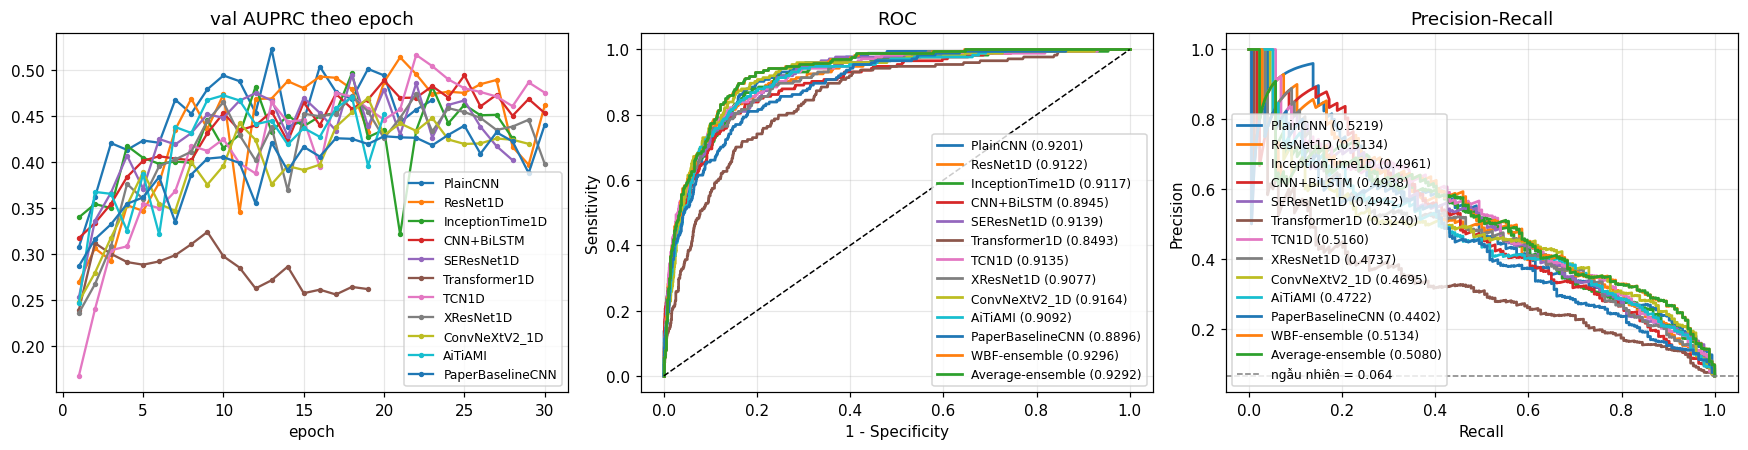

In [42]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))

for name, r in RESULTS.items():
    if "hist" not in r:      # các dòng ensemble không có lịch sử train riêng
        continue
    h = pd.DataFrame(r["hist"])
    ax[0].plot(h.epoch, h.val_auprc, marker="o", ms=2.5, label=name)
ax[0].set_title("val AUPRC theo epoch"); ax[0].set_xlabel("epoch")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

base = float(np.mean(next(iter(RESULTS.values()))["y"]))
for name, r in RESULTS.items():
    if len(np.unique(r["y"].astype(int))) != 2:
        continue
    fpr, tpr, _ = roc_curve(r["y"], r["p"])
    ax[1].plot(fpr, tpr, lw=1.8, label=f"{name} ({r['metrics']['auroc']:.4f})")
    prec, rec, _ = precision_recall_curve(r["y"], r["p"])
    ax[2].plot(rec, prec, lw=1.8, label=f"{name} ({r['metrics']['auprc']:.4f})")

ax[1].plot([0, 1], [0, 1], "k--", lw=1)
ax[1].set_xlabel("1 - Specificity"); ax[1].set_ylabel("Sensitivity")
ax[1].set_title("ROC"); ax[1].legend(fontsize=8); ax[1].grid(alpha=.3)

ax[2].axhline(base, ls="--", c="gray", lw=1, label=f"ngẫu nhiên = {base:.3f}")
ax[2].set_xlabel("Recall"); ax[2].set_ylabel("Precision")
ax[2].set_title("Precision-Recall"); ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)

plt.tight_layout()
plt.show()

## 17. Lưu ý khi kết luận

**Không dùng notebook này để nói "đã tái lập được baseline của paper".** `PaperBaselineCNN` tái hiện
đúng *sơ đồ kết nối và số kênh* ở Fig. 9, nhưng ăn input khác (raw 12×5000 thay vì median beat
12×500), có thêm BatchNorm, head khác, và quan trọng nhất là **đo trên tập khác**: validation tách
từ train, không phải tập test ẩn 1.995 bản ghi mà paper dùng. Con số AUROC 0,900 của họ là mốc tham
chiếu, không phải mục tiêu để đạt bằng được.

**Nhãn OMI có giới hạn mà chính tác giả thừa nhận.** Phần Limitation của paper nói rõ: họ không có
chẩn đoán OMI đã được hội đồng phân xử (adjudicated), nên `OMI = 1` chỉ bắt các ca **tắc hoàn toàn
TIMI 0–1 tại thời điểm chụp mạch**. Những ca **tự tái tưới máu trước khi chụp** (TIMI 2–3 kèm
troponin đỉnh cao) bị xếp thành âm tính dù về bản chất là OMI. Đây là **false negative nằm sẵn trong
nhãn**, không phải lỗi mô hình — và nó kéo trần hiệu năng đo được xuống thấp hơn thực tế.

**OMI khó hơn STEMI về bản chất sinh lý bệnh, không phải vì mô hình kém.** ST chênh lên là một mẫu
hình thị giác tương đối rõ; tắc mạch thì không phải lúc nào cũng để lại dấu vết trên một bản ECG 10
giây đơn lẻ. Ngay cả chuyên gia đọc mù cũng chỉ đạt độ nhạy 0,277–0,429 trên bài toán này. Vì vậy
AUROC OMI thấp hơn AUROC STEMI của notebook 03 là **kết quả mong đợi**, không phải dấu hiệu hỏng.

**`AiTiAMI` là tái hiện theo mô tả kiến trúc, không phải model gốc của Medical AI Co.** (xem cảnh báo
ở mục 12). Không dùng kết quả của nó để phát biểu gì về sản phẩm thương mại thật.

**Ensemble WBF không đảm bảo luôn thắng model tốt nhất đơn lẻ.** Nếu các model mắc cùng loại lỗi
(cùng nhầm ở những ca khó giống nhau), hợp nhất xác suất sẽ không thêm được thông tin mới — đó là
kết quả hợp lệ cần báo cáo trung thực, không phải lý do chỉnh trọng số để "ép" ensemble thắng.

**Đừng đọc chênh lệch nhỏ như một cải thiện thật.** Seed đã cố định, nhưng `cudnn.benchmark` và AMP
khiến mỗi lần chạy lại lệch khoảng **±0,015 AUROC**. Hai mô hình cách nhau dưới ~0,015 AUROC nên coi
là **ngang nhau**. Với phân nhóm NSTEMI ở mục 15b, cỡ mẫu chỉ khoảng 180 bản ghi
(~60 ca dương) nên dao động lớn hơn nhiều — hãy đọc nó như một tín hiệu định hướng, không phải một
con số chốt. Muốn kết luận chắc về nhóm này cần bootstrap khoảng tin cậy hoặc gộp nhiều seed.

**Chỉ có một lần chia train/val**, chưa cross-validation, nên khoảng tin cậy của các metric chưa được
ước lượng. Paper dùng 5-fold CV cho baseline của họ.

**Tập test ẩn 10% không được đụng tới** ở bất kỳ bước nào — cả việc chọn mô hình lẫn chọn ngưỡng đều
làm trên validation. Muốn có số so được trực tiếp với paper thì phải nộp dự đoán lên nền tảng chấm
điểm trực tuyến mà tác giả cung cấp (địa chỉ ghi trong bài báo, mục Data overview).

---

## 18. Chuyển từ chạy thử sang chạy thật

Ở **mục 2**, đổi `RUN_MODE = "debug"` thành `RUN_MODE = "full"` rồi **Run all**.

Chế độ `full` train cả mười một mô hình trên 17.960 bản ghi, tối đa 30 epoch mỗi mô hình — khoảng
**40–60 phút** trên GPU rời, **1,5–3 giờ** trên Colab T4. `PaperBaselineCNN` dùng kernel 71 rất rộng
trên chuỗi dài 1.250 nên nặng hơn `PlainCNN` khá nhiều dù ít tham số.

Notebook này dùng **chung file cache** với `01_stemi_classifier.ipynb` và `03_stemi_model_comparison.ipynb`
ở chế độ `full` (cùng danh sách bản ghi → cùng tên cache), nên nếu đã chạy một trong hai notebook kia
thì bước tiền xử lý được bỏ qua hoàn toàn.

**Nếu phiên Colab đứt giữa chừng:** Run all lại. Những mô hình đã train xong được nạp từ checkpoint
và bỏ qua, chỉ train tiếp phần còn thiếu. Checkpoint của notebook này nằm ở `models/omi_compare/`,
tách khỏi `models/stemi_compare/` của notebook 03.

---

## 19. Hướng mở rộng: dùng median beat 12×500 như paper

Paper huấn luyện baseline trên **median waveform** (file `.med`), không phải tín hiệu thô. Định dạng
`.med` đã được xác minh: mỗi file đúng 12.000 byte = **500 mẫu × 12 chuyển đạo, `int16`, xen kẽ theo
mẫu** (giá trị tại vị trí `i` và `i+12` là hai mẫu liên tiếp của cùng một chuyển đạo). Đọc bằng:

```python
sig = np.fromfile(path, dtype="<i2").reshape(500, 12).T   # -> (12, 500)
```

Chạy lại toàn bộ so sánh trên input này sẽ cho phép đối chiếu sát hơn với con số của paper, đổi lại
phải dựng cache thứ hai và kiểm tra kỹ những kiến trúc hạ chiều thời gian mạnh (5 tầng stride 2)
xem còn đủ độ dài ở 500 mẫu không. Notebook hiện tại **không** làm việc này — mọi model ở đây đều ăn
raw 12×5000 để so sánh giữa 11 kiến trúc là công bằng.